In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
import os
import random
import time
import numpy as np
import pickle as p
import copy
import sys
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter



# Overview
---
Evolutionary neural architecture search (NAS) experiment using the NSGA-II multi-objective genetic algorithm on the NAS-Bench-201 benchmark. The goal is to automatically discover neural network architectures that balance efficiency (e.g., FLOPs) and performance (e.g., validation error). The code is modified and originates from https://github.com/ELO-Lab/E-TF-MOENAS and https://github.com/anyoptimization/pymoo.

# Data Installation
---
Data links found in the install.sh file of https://github.com/ELO-Lab/E-TF-MOENAS. Download the following to the specified locations on google drive.

- https://drive.google.com/uc?id=1Ud4GF-3264R0rkqOmBK46L9S_kalN01z - /content/drive/data/NASBench201/[CIFAR-10]_data.p
- https://drive.google.com/uc?id=1mow6Cqwgs3DnKngF6reF7STsVa7KS15R - /content/drive/data/NASBench201/[CIFAR-100]_data.p
- https://drive.google.com/uc?id=1LSqvNkFzsRldW2kgCaSao9uCdYpN525H - /content/drive/data/NASBench201/[ImageNet16-120]_data.p
- https://drive.google.com/uc?id=1Zbb_StAGgX6HYHHuoZWPY8PLb0DhDzKY - /content/drive/data/NASBench201/zc_nasbench201.json
- https://drive.google.com/uc?id=1DRRnPJOvKwOE1g4n9TuoOP6bQ5KjGnwl - /content/drive/data/NASBench201/logsynflow_nwot.p

# Utils
---
Utility functions to support the evolutionary search algorithm and visualisations.

In [2]:
def check_valid(hash_key, **kwargs):
    """
    Check whether a candidate architecture is new across all provided collections. Used to prevent duplicate architectures from entering the population or offspring.

    Args:
        hash_key: The hash key of the candidate architecture to check.
        **kwargs: Named collections of existing hash keys to check against.
            The candidate is considered valid only if it is absent from all of them.

    Returns:
        True if the hash key is not found in any of the provided collections,
        False if it already exists in at least one.
    """
    return np.all([hash_key not in kwargs[L] for L in kwargs])

def get_hashKey(arch):
    """
    Compute a string hash key that uniquely identifies an architecture.

    Args:
        arch: The compact architecture representation as an array of integer operation indices.

    Returns:
        A string that uniquely identifies the architecture within the
        search space.
    """
    arch_dummy = arch.copy()
    return ''.join(map(str, arch_dummy))

def do_each_gen(**kwargs):
    """
    Records a snapshot of the current search state by appending the evaluation count and elapsed running time, along with the latest
    elitist archive state, to their respective per-generation history lists.

    Args:
        **kwargs: Must contain:
            algorithm: The running algorithm instance.
    """
    algorithm = kwargs['algorithm']

    algorithm.nEvals_runningtime_each_gen.append([algorithm.n_eval, algorithm.running_time_history[-1]])
    algorithm.E_Archive_search_each_gen.append(algorithm.E_Archive_search_history[-1].copy())

def finalize(**kwargs):
    """
    Persists all accumulated search history to disk as pickle files in the algorithm's result directory. Three files are written:
        #Evals_runningtime_each_gen.p: List of [n_eval, running_time] pairs, one per generation. For plotting convergence speed over
            wall-clock time.
        E_Archive_search_each_gen.p: List of elitist archive snapshots, one per generation. Each snapshot is a dict with keys 'X', 'hashKey',
            and 'F', capturing how the Pareto front evolved over generations.
        #Evals_and_Elitist_Archive_search.p: A tuple of [nEvals_history, E_Archive_search_history], logged only at moments when the elitist
            archive changed. For finer-grained analysis of archive improvement events.

    Args:
        **kwargs: Must contain:
            algorithm: The completed algorithm instance.
    """
    algorithm = kwargs['algorithm']

    p.dump(algorithm.nEvals_runningtime_each_gen, open(f'{algorithm.res_path}/#Evals_runningtime_each_gen.p', 'wb'))
    p.dump(algorithm.E_Archive_search_each_gen, open(f'{algorithm.res_path}/E_Archive_search_each_gen.p', 'wb'))

    p.dump([algorithm.nEvals_history, algorithm.E_Archive_search_history],
           open(f'{algorithm.res_path}/#Evals_and_Elitist_Archive_search.p', 'wb'))


In [ ]:
def func_euclidean_distance(a, b):
    return np.sqrt(((a - b) ** 2).sum(axis=1))


def at_least_2d_array(x, extend_as="row", return_if_reshaped=False):
    if x is None:
        return x
    elif not isinstance(x, np.ndarray):
        x = np.array([x])

    has_been_reshaped = False

    if x.ndim == 1:
        if extend_as.startswith("r"):
            x = x[None, :]
        elif extend_as.startswith("c"):
            x = x[:, None]
        else:
            raise Exception("The option `extend_as` should be either `row` or `column`.")

        has_been_reshaped = True

    if return_if_reshaped:
        return x, has_been_reshaped
    else:
        return x

def vectorized_cdist(A, B, func_dist=func_euclidean_distance, fill_diag_with_inf=False, **kwargs) -> object:
    assert A.ndim <= 2 and B.ndim <= 2

    A, only_row = at_least_2d_array(A, extend_as="row", return_if_reshaped=True)
    B, only_column = at_least_2d_array(B, extend_as="row", return_if_reshaped=True)

    u = np.repeat(A, B.shape[0], axis=0)
    v = np.tile(B, (A.shape[0], 1))

    D = func_dist(u, v, **kwargs)
    M = np.reshape(D, (A.shape[0], B.shape[0]))

    if fill_diag_with_inf:
        np.fill_diagonal(M, np.inf)

    if only_row and only_column:
        M = M[0, 0]
    elif only_row:
        M = M[0]
    elif only_column:
        M = M[:, [0]]

    return M


class Normalization:
    def __init__(self) -> None:
        super().__init__()

    def forward(self, X):
        pass

    def backward(self, X):
        pass

class NoNormalization(Normalization):
    def forward(self, X):
        return X

    def backward(self, X):
        return X

class ZeroToOneNormalization(Normalization):
    def __init__(self, xl=None, xu=None) -> None:
        super().__init__()

        # if both are None we are basically done because normalization is disabled
        if xl is None and xu is None:
            self.xl, self.xu = None, None
            return

        # if not set simply fall back no nan values
        if xl is None:
            xl = np.full_like(xu, np.nan)
        if xu is None:
            xu = np.full_like(xl, np.nan)

        xl, xu = np.copy(xl).astype(float), np.copy(xu).astype(float)

        # if both are equal then set the upper bound to none (always the 0 or lower bound will be returned then)
        xu[xl == xu] = np.nan

        # store the lower and upper bounds
        self.xl, self.xu = xl, xu

        # check out when the input values are nan
        xl_nan, xu_nan = np.isnan(xl), np.isnan(xu)

        # now create all the masks that are necessary
        self.xl_only, self.xu_only = np.logical_and(~xl_nan, xu_nan), np.logical_and(xl_nan, ~xu_nan)
        self.both_nan = np.logical_and(np.isnan(xl), np.isnan(xu))
        self.neither_nan = np.logical_and(~np.isnan(xl), ~np.isnan(xu))

        # if neither is nan than xu must be greater or equal than xl
        any_nan = np.logical_or(np.isnan(xl), np.isnan(xu))
        assert np.all(np.logical_or(xu >= xl, any_nan)), "xl must be less or equal than xu."

    def forward(self, X):
        if X is None or (self.xl is None and self.xu is None):
            return X

        # simple copy the input
        N = np.copy(X)

        # normalize between zero and one if neither of them is nan
        N[...,  self.neither_nan] = (X[...,  self.neither_nan] - self.xl[self.neither_nan]) / (self.xu[self.neither_nan] - self.xl[self.neither_nan])

        N[..., self.xl_only] = X[..., self.xl_only] - self.xl[self.xl_only]

        N[..., self.xu_only] = 1.0 - (self.xu[self.xu_only] - X[..., self.xu_only])

        return N

    def backward(self, N):
        if N is None or (self.xl is None and self.xu is None):
            return N

        xl, xu, xl_only, xu_only = self.xl, self.xu, self.xl_only, self.xu_only
        both_nan, neither_nan = self.both_nan, self.neither_nan

        X = N.copy()
        X[..., neither_nan] = xl[neither_nan] + N[..., neither_nan] * (xu[neither_nan] - xl[neither_nan])

        X[..., xl_only] = N[..., xl_only] + xl[xl_only]

        X[..., xu_only] = xu[xu_only] - (1.0 - N[..., xu_only])

        return X

class PreNormalization:

    def __init__(self, zero_to_one=False, ideal=None, nadir=None, **kwargs):

        # normalization related stuff if that should be performed beforehand
        self.ideal, self.nadir = ideal, nadir

        if zero_to_one:
            assert self.ideal is not None and self.nadir is not None, "For normalization either provide pf or bounds!"

            n_dim = len(self.ideal)
            self.normalization = ZeroToOneNormalization(self.ideal, self.nadir)

            # now the ideal and nadir points have change to only zeros and ones
            self.ideal, self.nadir = np.zeros(n_dim), np.ones(n_dim)

        else:
            self.normalization = NoNormalization()

    def do(self, *args, **kwargs):
        pass

class Indicator(PreNormalization):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        # what should an indicator return if no solutions are provided is defined here
        self.default_if_empty = 0.0

    def __call__(self, F, *args, **kwargs):
        return self.do(F, *args, **kwargs)

    def do(self, F, *args, **kwargs):

        # if it is a 1d array
        if F.ndim == 1:
            F = F[None, :]

        # if no points have been provided just return the default
        if len(F) == 0:
            return self.default_if_empty

        # do the normalization - will only be done if zero_to_one is enabled
        F = self.normalization.forward(F)

        return self._do(F, *args, **kwargs)

    def _do(self, F, *args, **kwargs):
        return

def euclidean_distance(a, b, norm=None):
    return np.sqrt((((a - b) / norm) ** 2).sum(axis=1))


def derive_ideal_and_nadir_from_pf(pf, ideal=None, nadir=None):
    # try to derive ideal and nadir if not already set and pf provided
    if pf is not None:
        if ideal is None:
            ideal = np.min(pf, axis=0)
        if nadir is None:
            nadir = np.max(pf, axis=0)

    return ideal, nadir

class DistanceIndicator(Indicator):
    def __init__(self, pf, dist_func, axis, zero_to_one=False, ideal=None, nadir=None, norm_by_dist=False, **kwargs):

        # the pareto front if necessary to calculate the indicator
        pf = at_least_2d_array(pf, extend_as="row")
        ideal, nadir = derive_ideal_and_nadir_from_pf(pf, ideal=ideal, nadir=nadir)

        super().__init__(zero_to_one=zero_to_one, ideal=ideal, nadir=nadir, **kwargs)
        self.dist_func = dist_func
        self.axis = axis
        self.norm_by_dist = norm_by_dist
        self.pf = self.normalization.forward(pf)

    def _do(self, F):

        # a factor to normalize the distances by (1.0 disables that by default)
        norm = 1.0

        # if zero_to_one is disabled this can be used to normalize the distance calculation itself
        if self.norm_by_dist:
            assert self.ideal is not None and self.nadir is not None, "If norm_by_dist is enabled ideal and nadir must be set!"
            norm = self.nadir - self.ideal

        D = vectorized_cdist(self.pf, F, func_dist=self.dist_func, norm=norm)
        return np.mean(np.min(D, axis=self.axis))

def _hypervolume(F, ref):
    """
    Recursive WFG hypervolume algorithm.
    F: (n_points, n_obj) array, ref: (n_obj,) array.
    Assumes minimization; all points must dominate the ref.
    """
    def exclusive_hv(points, ref, idx):
        vol = inclusive_hv(points[idx], ref)
        if len(points) > idx + 1:
            vol -= _hypervolume(
                limit_set(points, idx), ref
            )
        return vol

    def inclusive_hv(point, ref):
        return np.prod(np.abs(ref - point))

    def limit_set(points, idx):
        dominated = []
        for i in range(idx + 1, len(points)):
            p = np.maximum(points[i], points[idx])
            dominated.append(p)
        return np.array(dominated)

    if len(F) == 0:
        return 0.0

    F = F[np.argsort(F[:, 0])]  # sort by first objective
    total = 0.0
    for i in range(len(F)):
        total += exclusive_hv(F, ref, i)
    return total

class HV(Indicator):
    def __init__(self, ref_point=None, pf=None, nds=True, norm_ref_point=True, ideal=None, nadir=None, **kwargs):

        pf = at_least_2d_array(pf, extend_as="row")
        ideal, nadir = derive_ideal_and_nadir_from_pf(pf, ideal=ideal, nadir=nadir)

        super().__init__(ideal=ideal, nadir=nadir, **kwargs)
        # self.normalization = ZeroToOneNormalization(ideal, nadir)

        # whether the input should be checked for domination or not (deprecated)
        self.nds = nds

        # the reference point that shall be used - either derived from pf or provided
        ref_point = ref_point
        if ref_point is None:
            if pf is not None:
                ref_point = pf.max(axis=0)

        # we also have to normalize the reference point to have the same scales
        if norm_ref_point:
            ref_point = self.normalization.forward(ref_point)

        self.ref_point = ref_point
        assert self.ref_point is not None, "For Hypervolume a reference point needs to be provided!"

    def _do(self, F):
        # calculate the hypervolume using moocore
        val = _hypervolume(F, ref = self.ref_point)
        return val

class IGD(DistanceIndicator):
    def __init__(self, pf, **kwargs):
        super().__init__(pf, euclidean_distance, 1, **kwargs)

def get_hashKey(arch):
    """
    Generates a hash key string from an architecture list or array.

    Args:
        arch: A list or array representing the architecture.

    Returns:
        A string concatenation of the elements in `arch`.
    """
    return ''.join(map(str, arch))

def find_the_better(x, y):
    """
    Compares two solutions to determine which one is better.

    Args:
        x: A list or array representing the first solution.
        y: A list or array representing the second solution.

    Returns:
        int: -1 if solutions are incomparable,
             0 if x is better than y,
             1 if y is better than x.
    """
    if isinstance(x, list):
        x = np.array(x)
    if isinstance(y, list):
        y = np.array(y)
    sub_ = x - y
    x_better = np.all(sub_ <= 0)
    y_better = np.all(sub_ >= 0)
    if x_better == y_better:  # True - True
        return -1
    if y_better:  # False - True
        return 1
    return 0  # True - False

def get_front_0(F):
    """
    Identifies the non-dominated front (front 0) from a set of solutions.

    Args:
        F: A 2D numpy array of solution metrics.

    Returns:
        A boolean array indicating which solutions are in front 0.
    """
    l = len(F)
    r = np.zeros(l, dtype=np.int8)
    for i in range(l):
        if r[i] == 0:
            for j in range(i + 1, l):
                better_sol = find_the_better(F[i], F[j])
                if better_sol == 0:
                    r[j] += 1
                elif better_sol == 1:
                    r[i] += 1
                    break
    return r == 0

def calculate_HV(af):
    """
    Calculates the Hypervolume (HV) for a set of solutions.

    Args:
        af: A 2D numpy array representing the approximation front.

    Returns:
        float: The normalized HV value rounded to 6 decimals.
    """
    hv_value = HV_computing(af)
    return np.round(hv_value / np.prod(reference_point), 6)

def evaluate(list_arch):
    """
    Evaluates a list of architectures and computes their approximation front and metrics.

    Args:
        list_arch: A list of architectures to evaluate.

    Returns:
        dict: A dictionary containing:
            - 'Approximation Set': The set of non-dominated architectures.
            - 'Approximation Front': The corresponding metrics.
            - 'IGD': IGD value of the front.
            - 'HV': Hypervolume value of the front.
            - 'Best testing accuracy': Best test accuracy percentage.
    """
    F = []
    for arch in list_arch:
        hashKey = get_hashKey(arch)
        test_error = np.round(1 - benchmark_data['200'][hashKey]['test_acc'][-1], 4)
        efficiency_metric = np.round(benchmark_data['200'][hashKey]['FLOPs'], 4)
        f = [test_error, efficiency_metric]
        F.append(f)

    F = np.array(F)
    list_arch = np.array(list_arch)
    fr0 = get_front_0(F)
    AF = F[fr0]
    AF = np.unique(AF, axis=0)
    AS = list_arch[fr0]
    hv_value = calculate_HV(AF)
    best_test_acc = np.round((1 - np.min(AF[:, 0])) * 100, 2)
    opt_results = {
        'Approximation Set': AS,
        'Approximation Front': AF,
        'HV': hv_value,
        'Best testing accuracy': best_test_acc,
    }
    return opt_results

def summarize_results():
    """
    Loads and processes experimental results from different NAS algorithms, and saves the raw combined results per algorithm variant.
    
    Raises:
        FileNotFoundError: If experiment directories do not exist.
    """
    list_variant = [
        'val_error', 'val_loss', 'train_loss'
    ]
    print('Summarising results')
    for variant in list_variant:
        #print('Algorithm:', variant)
        algo_res_path = f'{RES_PATH}/NAS201-{dataset_abbrev}_{variant}'

        if not os.path.exists(algo_res_path):
           print(f'{algo_res_path} does not exist')
           continue
        nEvals_all = []
        rt_all = []
        EA_all = []
        HV_all = []
        list_exp = list(os.listdir(algo_res_path))
        for rid in list_exp:
            if 'txt' in rid:
                continue
            HV_history = []
            EA_history = []

            exp_res_path = algo_res_path + f'/{rid}'

            nEvals_runningtime_each_gen = p.load(open(exp_res_path + '/#Evals_runningtime_each_gen.p', 'rb'))
            nEvals_runningtime_each_gen = np.array(nEvals_runningtime_each_gen)

            nEvals_history = (nEvals_runningtime_each_gen[:, 0].astype(int)).tolist()
            running_time_history = (nEvals_runningtime_each_gen[:, 1].astype(int) + 1).tolist()

            E_Archive_search_each_gen = p.load(open(exp_res_path + '/E_Archive_search_each_gen.p', 'rb'))
            for EA in E_Archive_search_each_gen:
                rs_evaluation = evaluate(EA['X'])

                ea = {
                    'X_lst': rs_evaluation['Approximation Set'],
                    'F_lst': rs_evaluation['Approximation Front'],
                }

                hv_value = rs_evaluation['HV']

                EA_history.append(ea)
                HV_history.append(hv_value)

            nEvals_all.append(nEvals_history)
            rt_all.append(running_time_history)
            EA_all.append(EA_history)
            HV_all.append(HV_history)

        nEvals_all = np.array(nEvals_all)
        rt_all = np.array(rt_all)

        nEvals_all = np.array(nEvals_all)
        rt_all = np.array(rt_all)
        HV_all = np.array(HV_all)

        rs_all = {
            'nEvals_all': nEvals_all,
            'running_time_all': rt_all,
            'EA_all': EA_all,
            'HV_all': HV_all,
        }
        p.dump(rs_all, open(f'{RES_PATH}/raw_results_{variant}_{dataset_abbrev}.p', 'wb'))


def processing_results():
    """
    Processes the raw experimental results, extracts final metrics for each algorithm, and saves them in a summarised form.
    """
    list_variant = [
        'val_error', 'val_loss', 'train_loss'
    ]
    print('Processing results')
    for variant in list_variant:
        #print('Algorithm:', variant)
        raw_res = p.load(open(f'{RES_PATH}/raw_results_{variant}_{dataset_abbrev}.p', 'rb'))

        best_arch_found = []
        final_EA = []
        final_HV = []
        final_running_time = []

        n_run = len(raw_res['EA_all'])
        for i in range(n_run):
            EA = raw_res['EA_all'][i][-1]
            F = EA['F_lst']
            best_arch = np.round((1 - np.min(F[:, 0])) * 100, 2)
            HV_value = raw_res['HV_all'][i][-1]
            rt = raw_res['running_time_all'][i][-1]

            best_arch_found.append(best_arch)
            final_HV.append(HV_value)
            final_running_time.append(rt)
            final_EA.append(EA)

        rs_final = {
            'best_arch_found': best_arch_found,
            'final_EA': final_EA,
            'final_HV': final_HV,
            'running_time_avg': int(np.mean(final_running_time)) + 1
        }
        p.dump(rs_final, open(f'{RES_PATH}/{variant}_{dataset_abbrev}.p', 'wb'))

def visualize_mean_std(obj0_mean, obj1_mean, obj1_std, label, line):
    color = line[0]
    style = line[1]
    ax.plot(obj0_mean, obj1_mean, c=color, ls=style, label=label, linewidth=1.5)
    ax.fill_between(obj0_mean, obj1_mean - obj1_std, obj1_mean + obj1_std, alpha=0.1, fc=color)

def visualize_xaxis_nEvals():
    list_variant = [
        'train_loss',
        'val_error',
        'val_loss'
        #'synflow',
        #'jacov',
        #'E-TF-MOENAS',
        #'E-TF-MOENAS-C'
    ]

    labels = [
        'NSGAII (train-loss)',
        'NSGAII (val-error)',
        'NSGAII (val-loss)',
        #'NSGAII (jacov)',
        #'E-TF-MOENAS (Ours)',
        #'E-TF-MOENAS-C (Ours)'
    ]

    colors = {
        'NSGAII (train-loss)': ['green', '-.'],
        'NSGAII (val-error)': ['tab:orange', '-.'],
        'NSGAII (val-loss)': ['purple', '-.'],
        #'E-TF-MOENAS (Ours)': ['red', '-.'],
        #'E-TF-MOENAS-C (Ours)': ['brown', '-.'],
    }

    list_raw_res = [f'{RES_PATH}/raw_results_{variant}_{dataset_abbrev}.p' for variant in list_variant]

    algo_hv_mean = []
    algo_hv_std = []

    algo_nEvals = []
    for raw_res in list_raw_res:
        res = p.load(open(raw_res, 'rb'))
        HV_all = res['HV_all']
        nEvals = res['nEvals_all'][0]

        HV_mean = np.mean(HV_all, axis=0)
        HV_std = np.std(HV_all, axis=0)

        algo_hv_mean.append(HV_mean)
        algo_hv_std.append(HV_std)

        algo_nEvals.append(nEvals)

    ends = [20, 100, 1000, 3000]

    for i in range(len(algo_hv_mean)):
        visualize_mean_std(algo_nEvals[i], algo_hv_mean[i], algo_hv_std[i], labels[i], line=colors[labels[i]])

    ax.set_xscale('log')
    ax.set_xticks(ends)
    ax.get_xaxis().set_major_formatter(FormatStrFormatter('%.2d'))
    ax.set_xlabel('#Evals')
    ax.set_ylabel(metric)

    #plt.title('NASBench201', fontsize=20)

    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.1, box.width, box.height * 0.9])
    ax.grid(True, linestyle='--')
    ax.legend(loc=4)
    #plt.savefig(f'{RES_PATH}/nEvals_{metric}_201_{dataset_abbrev}.jpg', bbox_inches='tight', pad_inches=0.1, dpi=300)

def visualize_xaxis_hours():
    list_variant = [
        'train_loss',
        'val_error',
        'val_loss',
        #'jacov',
        #'E-TF-MOENAS',
        #'E-TF-MOENAS-C'
    ]

    labels = [
        'NSGAII (train-loss)',
        'NSGAII (val-error)',
        'NSGAII (val-loss)',
        #'E-TF-MOENAS (Ours)',
        #'E-TF-MOENAS-C (Ours)'
    ]

    colors = {
        'NSGAII (train-loss)': ['green', '-.'],
        'NSGAII (val-error)': ['tab:orange', '-.'],
        'NSGAII (val-loss)': ['purple', '-.'],
        #'E-TF-MOENAS (Ours)': ['red', '-.'],
        #'E-TF-MOENAS-C (Ours)': ['brown', '-.'],
    }

    list_raw_res = [f'{RES_PATH}/raw_results_{variant}_{dataset_abbrev}.p' for variant in list_variant]

    algo_hv_mean = []
    algo_hv_std = []

    algo_rt = []

    for raw_res in list_raw_res:
        res = p.load(open(raw_res, 'rb'))
        HV_all = res['HV_all']
        rt_all = res['running_time_all']

        HV_mean = np.mean(HV_all, axis=0)
        HV_std = np.std(HV_all, axis=0)

        rt_mean = np.round(np.mean(rt_all, axis=0)/3600, 4)

        algo_hv_mean.append(HV_mean)
        algo_hv_std.append(HV_std)

        algo_rt.append(rt_mean)

    ends = [0.0118, 0.0186, 0.6033, 1.623, 2.6864, 88.3908]

    for i in range(len(algo_hv_mean)):
        visualize_mean_std(algo_rt[i], algo_hv_mean[i], algo_hv_std[i], labels[i], line=colors[labels[i]])

    ax.set_xscale('log')
    ax.set_xticks(ends)
    ax.get_xaxis().set_major_formatter(FormatStrFormatter('%.2f'))
    ax.set_xlabel('GPUs Hours')
    ax.set_ylabel(metric)
    plt.xticks(rotation=90)

    ax.grid(True, linestyle='--')
    ax.legend(loc=4)
    #plt.title('NASBench201', fontsize=20)
    #plt.savefig(f'{RES_PATH}/runtime_{metric}_201_{dataset_abbrev}.jpg', bbox_inches='tight', pad_inches=0.1, dpi=300)

def draw(metric):
    list_algo = [
        'train_loss',
        'val_error',
        'val_loss',
    ]
    list_xticks = [
        'NSGAII (train-loss)',
        'NSGAII (val-error)',
        'NSGAII (val-loss)',
    ]
    list_color = ['green', 'tab:orange', 'purple'] #, 'black', 'tab:olive', 'tab:cyan', 'red']

    plt.grid(True, axis='y', linestyle='--', zorder=0)

    for i, algo in enumerate(list_algo):
        mean, std = algo_perf[dataset_abbrev][algo][metric]['mean'], algo_perf[dataset_abbrev][algo][metric]['std']
        (_, caps, _) = plt.errorbar(i, mean, yerr=std, fmt='.', capsize=10, linewidth=4, color=list_color[i], zorder=i+2, markersize=18, label=list_xticks[i])
        for cap in caps:
            cap.set_markeredgewidth(2)

    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    plt.title(metric + f' ({dataset})', fontsize=20)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.1, box.width, box.height * 0.9])
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), fancybox=True, shadow=True, ncol=4)

    plt.savefig(f'{RES_PATH}/201_{dataset_abbrev}_transfer_{metric}.jpg', bbox_inches='tight', pad_inches=0.1, dpi=300)

     

# Representation
---
Data structures for the evolutionary algorithm. Individual represents a single candidate architecture with its encoding, fitness values, and metadata. Population is a NumPy array subclass that holds a collection of individuals and provides vectorized bulk get/set operations over them. They allow the algorithm to treat a group of architectures as a single object while still accessing each individual's attributes efficiently.

In [5]:
class Individual:
    """
    Represents a single candidate architecture in the evolutionary search.

    Attributes:
        X: The compact architecture encoding.
        F: The evaluated objective values as a list.
        hashKey: A string uniquely identifying this architecture.
        age: An integer counter tracking how many generations this individual has survived.
        data: A dict storing any additional keyword attributes.
    """
    def __init__(self, **kwargs) -> None:
        self.X = None
        self.F = None
        self.hashKey = None
        self.age = 0
        self.data = kwargs

    def set(self, key, value):
        """
        Set an attribute value by name.

        Checks the instance's core attributes first, then falls back to
        the data dict. If the key does not exist in either location,
        no action is taken.

        Args:
            key: The name of the attribute to set, e.g. 'X', 'F', 'rank'.
            value: The value to assign to the attribute.
        """
        if key in self.__dict__:
            self.__dict__[key] = value
        elif key in self.data:
            self.data[key] = value

    def copy(self):
        """
        Create a shallow copy of this individual.

        Returns:
            A new Individual instance with the same attribute values and a copied data dict.
        """
        ind = copy.copy(self)
        ind.data = self.data.copy()
        return ind

    def get(self, key):
        """
        Retrieve an attribute value by name.

        Args:
            key: The name of the attribute to retrieve.

        Returns:
            The value of the attribute if found, otherwise None.
        """
        if key in self.__dict__:
            return self.__dict__[key]
        if key in self.data:
            return self.data[key]
        return None

class Population(np.ndarray):
    """
    A NumPy array subclass representing a collection of Individual objects.

    Attributes:
        individual: The prototype Individual instance used when creating new empty populations of the same type.
    """
    def __new__(cls, n_individuals=0, individual=Individual(), *args, **kwargs):
        """
        Allocate and initialise a new Population array.
        Args:
            n_individuals: The number of individuals to allocate space for.
            individual: A prototype Individual instance whose type and default attributes define the structure of each element.

        Returns:
            A new Population instance with n_individuals copied elements.
        """
        obj = super(Population, cls).__new__(cls, n_individuals, dtype=individual.__class__).view(cls)
        for i in range(n_individuals):
            obj[i] = individual.copy()
        obj.individual = individual
        return obj

    def merge(self, other):
        """
        Concatenate this population with another into a single Population.

        Args:
            other: Another Population instance to append to this one.

        Returns:
            A new Population containing all individuals from both, with the prototype individual inherited from self.
        """
        obj = np.concatenate([self, other]).view(Population)
        obj.individual = self.individual
        return obj

    def __deepcopy__(self):
        """
        Override deep copy to use the Population's own copy method.

        Args:
            memo: The memo dict passed by the deep copy machinery.

        Returns:
            A copy of this Population as produced by self.copy().
        """
        return self.copy()

    def new(self, *args):
        """
        Create a new empty Population of a given size, optionally pre-filled.

        Args:
            *args: Either a single integer (size), or an attribute name followed by a list of values as accepted by set().

        Returns:
            A new Population instance, optionally populated with the provided attribute values.
        """
        if len(args) == 1:
            return Population(n_individuals=args[0], individual=self.individual)
        else:
            n = len(args[1]) if len(args) > 0 else 0
            pop = Population(n_individuals=n, individual=self.individual)
            if len(args) > 0:
                pop.set(*args)
            return pop

    def collect(self, func, as_numpy_array=True):
        """
        Apply a function to each individual and collect the results.

        Args:
            func: A callable that takes an Individual and returns a value.
            as_numpy_array: If True, wraps the result list in np.array().

        Returns:
            The collected values as a numpy array if as_numpy_array is True, otherwise as a plain list.
        """
        val = []
        for i in range(len(self)):
            val.append(func(self[i]))
        if as_numpy_array:
            val = np.array(val)
        return val

    def set(self, *args):
        """
        Set one or more attributes across all individuals in the population.

        Args:
            *args: Alternating attribute names and value lists.

        Raises:
            Exception: If any value list length does not match the population size.
        """
        for i in range(int(len(args) / 2)):
            key, values = args[i * 2], args[i * 2 + 1]
            if len(values) != len(self):
                raise Exception('Population Set Attribute Error: Number of values and population size do not match!')
            for j in range(len(values)):
                if key in self[j].__dict__:
                    self[j].__dict__[key] = values[j]
                else:
                    self[j].data[key] = values[j]

    def get(self, *args):
        """
        Retrieve one or more attributes from all individuals in the population.

        Args:
            *args: One or more attribute names to retrieve.

        Returns:
            If a single attribute name is given, returns a numpy array of that attribute's values across all individuals. If multiple
            names are given, returns a tuple of numpy arrays, one per name.
        """
        val = {}
        for c in args:
            val[c] = []

        for i in range(len(self)):
            for c in args:
                if c in self[i].__dict__:
                    val[c].append(self[i].__dict__[c])
                elif c in self[i].data:
                    val[c].append(self[i].data[c])
        res = [val[c] for c in args]

        if len(args) == 1:
            return np.array(res[0])
        else:
            return tuple(res)

    def __array_finalize__(self, obj):
        """
        NumPy hook called whenever a new Population view is created.

        Args:
            obj: The object from which this Population was created, or None if created from scratch.
        """
        if obj is None:
            return
        self.individual = getattr(obj, 'individual', None)


# Problem
---
Problem abstraction layer for the NAS experiment. Base Problem class that acts as an abstract interface. A concrete NASBench201 subclass that implements it by querying a pre-built benchmark database, and several standalone helper functions for encoding and converting architecture representations. Rather than training any network, NASBench201 simply looks up pre-computed metrics (accuracy, FLOPs, latency, etc.) from stored data files, making evaluation nearly instantaneous.
  

In [6]:
OP_NAMES_NB201 = ['skip_connect', 'none', 'nor_conv_3x3', 'nor_conv_1x1', 'avg_pool_3x3']
EDGE_LIST = ((1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4))
available_ops = [0, 1, 2, 3, 4]

class Problem:
    """
    Abstract base class defining the interface for a NAS benchmark problem.

    Attributes:
        max_eval: Maximum number of architecture evaluations allowed during the search.
        name: Name of the benchmark.
        objective_0: The first minimisation objective.
        objective_1: The second minimisation objective.
        D: A dictionary cache mapping architecture keys to previously retrieved metric values, avoiding redundant lookups.
    """
    def __init__(self, max_eval, name, dataset, **kwargs):
        self.max_eval = max_eval
        self.name = name
        self.dataset = dataset

        self.objective_0 = None
        self.objective_1 = None

        self.D = {}

    def reset(self):
        """
        Clear the metric cache.
        """
        self.D = {}

    def set_up(self):
        """
        Run benchmark-specific setup and validate that objectives are configured.

        Raises:
            ValueError: If either objective_0 or objective_1 is still None after _set_up() completes.
        """
        self._set_up()
        if (self.objective_0 is None) or (self.objective_1 is None):
            raise ValueError('The optimization objectives have not been set up.')

    def sample_a_compact_architecture(self):
        """
        Sample a random architecture from the search space.

        Returns:
            A compact architecture encoding as a numpy array of integer operation indices.
        """
        return self._get_a_compact_architecture()

    def get_computational_metric(self, arch, metric):
        """
        Query a computational efficiency metric for a given architecture.

        Args:
            arch: The compact architecture encoding.
            metric: The name of the metric to retrieve, e.g. 'flops', 'params', 'latency'.

        Returns:
            The scalar value of the requested computational metric.
        """
        return self._get_computational_metric(arch, metric)

    def get_performance_metric(self, arch, epoch, metric, subset):
        """
        Query a performance metric for a given architecture.

        Args:
            arch: The compact architecture encoding.
            epoch: The training epoch at which to retrieve the metric.
            metric: The type of metric to retrieve, e.g. 'accuracy', 'error', 'loss'.
            subset: The data split to query, one of 'train', 'val', 'test'.

        Returns:
            A tuple of (metric_value, benchmark_time, indicator_time).
        """
        return self._get_performance_metric(arch, epoch, metric, subset)

    def evaluate(self, arch, comp_metric, perf_metric, epoch, subset):
        """
        Evaluate both objectives for a given architecture.

        Args:
            arch: The compact architecture encoding.
            comp_metric: The computational metric to retrieve, e.g. 'flops', 'params', 'latency'.
            perf_metric: The performance metric to retrieve, e.g. 'error', 'accuracy', 'loss'.
            epoch: The training epoch at which to retrieve the performance metric.
            subset: The data split to query, one of 'train', 'val', 'test'.

        Returns:
            A tuple of (computational_metric, performance_metric, benchmark_time, indicator_time).
        """
        return self._evaluate(arch, comp_metric, perf_metric, epoch, subset)

    def isValid(self, arch):
        """
        Check whether an architecture encoding is valid for this benchmark.

        Args:
            arch: The compact architecture encoding to validate.

        Returns:
            True if the architecture exists in the benchmark, False otherwise.
        """
        return self._isValid(arch)

    def _set_up(self):
        pass

    def _get_a_compact_architecture(self):
        raise NotImplementedError

    def _get_computational_metric(self, arch, metric):
        raise NotImplementedError

    def _get_performance_metric(self, arch, epoch, metric, subset):
        raise NotImplementedError

    def _evaluate(self, X, comp_metric, perf_metric, epoch, subset):
        raise NotImplementedError

    def _isValid(self, arch):
        raise NotImplementedError

def encode_int_list_2_ori_input(int_list):
    """
    Convert a compact integer architecture encoding to a NASBench201 operation string.

    Args:
        int_list: A list or array of 6 integer operation indices, each in the range [0, 4].

    Returns:
        A formatted NASBench201 operation string.
    """
    list_ops = np.array(['none', 'skip_connect', 'nor_conv_1x1', 'nor_conv_3x3', 'avg_pool_3x3'])
    list_int_ops = np.array(int_list)
    list_str_ops = list_ops[list_int_ops]
    return '|{}~0|+|{}~0|{}~1|+|{}~0|{}~1|{}~2|'.format(*list_str_ops)

def convert_str_to_op_indices(str_encoding):
    """
    Convert a NASBench201 operation string back to a tuple of operation indices.

    Args:
        str_encoding: A NASBench201-format operation string.

    Returns:
        A tuple of 6 integers representing operation indices ordered by the edges defined in EDGE_LIST.
    """
    nodes = str_encoding.split('+')

    def get_op(x):
        return x.split('~')[0]

    node_ops = [list(map(get_op, n.strip()[1:-1].split('|'))) for n in nodes]

    enc = []
    for u, v in EDGE_LIST:
        enc.append(OP_NAMES_NB201.index(node_ops[v - 2][u - 1]))

    return tuple(enc)


def get_key_in_data(arch):
    """
    Compute the string key used to look up an architecture in the benchmark data.

    Args:
        arch: The compact architecture encoding as an array of integer operation indices.

    Returns:
        A concatenated string of the operation indices.
    """
    return ''.join(map(str, arch))


class NASBench201(Problem):
    """
    NAS-Bench-201 benchmark problem for multi-objective architecture search.

    Provides lookup-based evaluation of all architectures in the NASBench201 search space by querying a pre-computed database, avoiding the need to
    train any network during search. Supports multiple efficiency objectives (FLOPs, params, latency) and performance metrics (accuracy, error, loss,
    zero-cost proxies).

    Attributes:
        available_ops: List of valid integer operation indices [0..4].
        maxLength: Number of edges in the cell, fixed at 6.
        database_path: Path to the directory containing benchmark data files.
        data: The loaded benchmark data dictionary keyed by epoch and architecture hash.
        min_max: Optional min/max normalization bounds (unused currently).
        zc_predictor: An optional zero-cost predictor instance used when querying training-free indicators.
        zc_benchmark: Loaded zero-cost benchmark scores from JSON.
        logsynflow_nwot: Pre-computed logSynflow and NWOT scores per dataset.
    """
    def __init__(self, dataset, max_eval, **kwargs):
        super().__init__(max_eval, 'NASBench201', dataset, **kwargs)

        self.objective_0 = kwargs['f0']
        self.objective_1 = 'test_error'

        assert self.objective_0 in ['params', 'flops', 'latency'], ValueError(f'Wrong objective: {self.objective_0}')

        # 'none': 0
        # 'skip_connect': 1
        # 'nor_conv_1x1': 2
        # 'nor_conv_3x3': 3
        # 'avg_pool_3x3': 4
        self.available_ops = [0, 1, 2, 3, 4]
        self.maxLength = 6

        self.database_path = kwargs['database_path'] + '/NASBench201'
        self.data = None
        self.min_max = None

        self.zc_predictor = None

    def _set_up(self):
        """
        Load all benchmark data files required for evaluation.

        Raises:
            ValueError: If self.dataset is not one of the three supported subsets.
        """
        available_subsets = ['CIFAR-10', 'CIFAR-100', 'ImageNet16-120']
        if self.dataset not in available_subsets:
            raise ValueError(f'Just only supported these subsets: CIFAR-10; CIFAR-100; ImageNet16-120.'
                             f'{self.dataset} subset is not supported at this time.')

        f_data = open(f'{self.database_path}/[{self.dataset}]_data.p', 'rb')
        self.data = p.load(f_data)
        f_data.close()

        import json
        self.zc_benchmark = json.load(open(self.database_path + '/zc_nasbench201.json'))

        self.logsynflow_nwot = p.load(open(self.database_path + '/logsynflow_nwot.p', 'rb'))

        print('--> Set Up - Done')

    def set_zero_cost_predictor(self, zc_predictor):
        """
        Attach a zero-cost predictor to be used during training-free evaluation.

        Args:
            zc_predictor: A predictor object with a method_type attribute specifying which zero-cost metric(s) to query.
        """
        self.zc_predictor = zc_predictor
        self.zc_predictor = zc_predictor

    def _get_a_compact_architecture(self):
        """
        Sample a random architecture from the NASBench201 search space.

        Returns:
            A numpy array of 6 randomly chosen integer operation indices, each in the range [0, 4].
        """
        return np.random.choice(self.available_ops, self.maxLength)

    """--------------------------------------------- Performance Metrics --------------------------------------------"""
    def get_cost_time(self, arch, epoch):
        """
        Retrieve the estimated training cost time for an architecture.

        Args:
            arch: The compact architecture encoding.
            epoch: The number of training epochs to compute cost for.

        Returns:
            The estimated training cost time in seconds as a float.
        """
        key = get_key_in_data(arch)
        if key not in self.D.keys():
            if self.dataset == 'CIFAR-10':
                cost_time = self.data['200'][key]['train_time'] / 2 * epoch
            else:
                cost_time = self.data['200'][key]['train_time'] * epoch
            self.D[key] = {'cost_time': cost_time}
        else:
            try:
                cost_time = self.D[key]['cost_time']
            except KeyError:
                if self.dataset == 'CIFAR-10':
                    cost_time = self.data['200'][key]['train_time'] / 2 * epoch
                else:
                    cost_time = self.data['200'][key]['train_time'] * epoch
                self.D[key]['cost_time'] = cost_time
        return cost_time

    def get_accuracy(self, arch, epoch, subset):
        """
        Retrieve the classification accuracy for an architecture.

        Args:
            arch: The compact architecture encoding.
            epoch: The training epoch to query. Use -1 for the final epoch.
            subset: The data split to query, one of 'train', 'val', 'test'.

        Returns:
            A tuple of (accuracy, benchmark_time, indicator_time) where accuracy is rounded to 4 decimal places.

        Raises:
            ValueError: If subset is not one of 'train', 'val', 'test'.
        """
        epoch_ = epoch if epoch == -1 else epoch - 1
        indicator_time = 0.0
        key = get_key_in_data(arch)
        if key not in self.D.keys():
            if subset == 'test':
                accuracy = self.data['200'][key]['test_acc'][epoch_]
                self.D[key] = {'test_acc': accuracy}
            elif subset == 'val':
                accuracy = self.data['200'][key]['val_acc'][epoch_]
                self.D[key] = {'val_acc': accuracy}
            elif subset == 'train':
                accuracy = self.data['200'][key]['train_acc'][epoch_]
                self.D[key] = {'train_acc': accuracy}
            else:
                raise ValueError()
        else:
            try:
                if subset == 'test':
                    accuracy = self.D[key]['test_acc']
                elif subset == 'val':
                    accuracy = self.D[key]['val_acc']
                elif subset == 'train':
                    accuracy = self.D[key]['train_acc']
                else:
                    raise ValueError()
            except KeyError:
                if subset == 'test':
                    accuracy = self.data['200'][key]['test_acc'][epoch_]
                    self.D[key]['test_acc'] = accuracy
                elif subset == 'val':
                    accuracy = self.data['200'][key]['val_acc'][epoch_]
                    self.D[key]['val_acc'] = accuracy
                elif subset == 'train':
                    accuracy = self.data['200'][key]['train_acc'][epoch_]
                    self.D[key] = {'train_acc': accuracy}
                else:
                    raise ValueError()
        benchmark_time = self.get_cost_time(arch, epoch)
        return np.round(accuracy, 4), benchmark_time, indicator_time

    def get_error(self, arch, epoch, subset):
        """
        Retrieve the classification error for an architecture.

        Args:
            arch: The compact architecture encoding.
            epoch: The training epoch to query. Use -1 for the final epoch.
            subset: The data split to query, one of 'train', 'val', 'test'.

        Returns:
            A tuple of (error, benchmark_time, indicator_time) where
            error is rounded to 4 decimal places.
        """
        accuracy, benchmark_time, indicator_time = self.get_accuracy(arch, epoch, subset)
        return np.round(1 - accuracy, 4), benchmark_time, indicator_time

    def get_tfi(self, arch):
        """
        Retrieve training-free indicator (zero-cost proxy) scores.

        Args:
            arch: The compact architecture encoding.

        Returns:
            A tuple of (score, benchmark_time, indicator_time) where score is a dict mapping metric name(s) to their scalar values, and
            indicator_time is the total query time summed across metrics.
        """
        benchmark_time = 0.0
        str_input = encode_int_list_2_ori_input(arch)
        op_indices = str(convert_str_to_op_indices(str_input))
        metric = self.zc_predictor.method_type
        score = {}
        indicator_time = 0.0
        if isinstance(metric, list):
            for m in metric:
                score[m] = self.zc_benchmark['cifar10'][op_indices][m]['score']
                indicator_time += self.zc_benchmark['cifar10'][op_indices][m]['time']
        else:
            score = {metric: self.zc_benchmark['cifar10'][op_indices][metric]['score']}
            indicator_time = self.zc_benchmark['cifar10'][op_indices][metric]['time']
        return score, benchmark_time, indicator_time

    def get_loss(self, arch, epoch, subset):
        """
        Retrieve the training or validation loss for an architecture.

        Args:
            arch: The compact architecture encoding.
            epoch: The training epoch to query (1-indexed).
            subset: The data split to query, one of 'train', 'val'.

        Returns:
            A tuple of (loss, benchmark_time, indicator_time) where loss is rounded to 4 decimal places.

        Raises:
            ValueError: If subset is not 'train' or 'val'.
        """
        key = get_key_in_data(arch)
        indicator_time = 0.0
        if key not in self.D.keys():
            if subset == 'train':
                loss = self.data['200'][key]['train_loss'][epoch - 1]
                self.D[key] = {'train_loss': loss}
            elif subset == 'val':
                loss = self.data['200'][key]['val_loss'][epoch - 1]
                self.D[key] = {'val_loss': loss}
            else:
                raise ValueError()
        else:
            try:
                if subset == 'train':
                    loss = self.D[key]['train_loss']
                elif subset == 'val':
                    loss = self.D[key]['val_loss']
                else:
                    raise ValueError()
            except KeyError:
                if subset == 'train':
                    loss = self.data['200'][key]['train_loss'][epoch - 1]
                    self.D[key] = {'train_loss': loss}
                elif subset == 'val':
                    loss = self.data['200'][key]['val_loss'][epoch - 1]
                    self.D[key] = {'val_loss': loss}
                else:
                    raise ValueError()
        benchmark_time = self.get_cost_time(arch, epoch)
        return np.round(loss, 4), benchmark_time, indicator_time

    def get_free_metrics(self, arch, metric):
        """
        Retrieve a training-free metric score following the FreeREA approach.

        Args:
            arch: The compact architecture encoding.
            metric: The training-free metric to retrieve. Must contain 'synflow' for synflow variants, or be exactly 'nwot'.

        Returns:
            A tuple of (score, indicator_time) where score is the scalar metric value and indicator_time is the benchmark query time.

        Raises:
            ValueError: If metric is not a synflow variant or 'nwot'.
        """
        str_input = encode_int_list_2_ori_input(arch)
        op_indices = str(convert_str_to_op_indices(str_input))

        key = get_key_in_data(arch)
        idx = self.data['200'][key]['idx']
        if self.dataset == 'CIFAR-10':
            dataset_ = 'cifar10'
        elif self.dataset == 'CIFAR-100':
            dataset_ = 'cifar100'
        else:
            dataset_ = self.dataset
        info = self.logsynflow_nwot[dataset_][idx][metric]
        score = info['score']
        if 'synflow' in metric:
            indicator_time = self.zc_benchmark['cifar10'][op_indices]['synflow']['time']
        elif metric == 'nwot':
            indicator_time = self.zc_benchmark['cifar10'][op_indices]['jacov']['time']
        else:
            raise ValueError
        return score, indicator_time

    @staticmethod
    def get_skip(arch):
        """
        Compute a skip-connection density score for an architecture.

        Args:
            arch: The compact architecture encoding.

        Returns:
            The average weighted skip-connection span as a float, or 0.0 if no skip connections are present.
        """
        genotype = encode_int_list_2_ori_input(arch)
        levels = genotype.split('+')
        max_len = 0
        counter = 0

        for idx, level in enumerate(levels):
            level = level.split('|')[1:-1]
            n_genes = len(level)

            for i in range(n_genes):
                if 'skip' in level[i]:
                    counter += 1
                    min_edge = idx - i
                    max_len += min_edge
        if counter:
            return max_len / counter
        return 0

    def _get_performance_metric(self, arch, epoch, metric='error', subset='val'):
        """
        Dispatch a performance metric query to the appropriate method.

        Args:
            arch: The compact architecture encoding.
            epoch: The training epoch to query.
            metric: The performance metric to retrieve. One of 'accuracy', 'error', 'loss', or a string containing 'tfi'. Use
                'negative_tfi' to negate zero-cost scores for minimization.
            subset: The data split to query, one of 'train', 'val', 'test'.

        Returns:
            A tuple of (perf_metric, benchmark_time, indicator_time).

        Raises:
            ValueError: If metric does not match any supported type.
        """
        if metric == 'accuracy':
            perf_metric, benchmark_time, indicator_time = self.get_accuracy(arch=arch, subset=subset, epoch=epoch)
        elif metric == 'error':
            perf_metric, benchmark_time, indicator_time = self.get_error(arch=arch, subset=subset, epoch=epoch)
        elif metric == 'loss':
            perf_metric, benchmark_time, indicator_time = self.get_loss(arch=arch, subset=subset, epoch=epoch)
        elif 'tfi' in metric:
            list_perf_metric, benchmark_time, indicator_time = self.get_tfi(arch=arch)
            if 'negative' in metric:  # in case we want to replace the error rate
                if len(list_perf_metric) > 1:
                    perf_metric = {}
                    for metric in list_perf_metric:
                        perf_metric[metric] = -list_perf_metric[metric]
                else:
                    for key in list_perf_metric.keys():
                        perf_metric = -list_perf_metric[key]
        else:
            raise ValueError()
        return perf_metric, benchmark_time, indicator_time

    """--------------------------------------------- Computational Metrics ------------------------------------------"""
    def get_FLOPs(self, arch):
        """
        Retrieve the number of floating point operations for an architecture.

        Args:
            arch: The compact architecture encoding.

        Returns:
            The number of FLOPs in giga-scale, rounded to 4 decimal places.
        """
        key = get_key_in_data(arch)
        nFLOPs = np.round(self.data['200'][key]['FLOPs'], 4)/1e3  # Convert to Giga (Millions at current) for reducing the IGD value
        return nFLOPs

    def get_params(self, arch):
        """
        Retrieve the number of trainable parameters for an architecture.

        Args:
            arch: The compact architecture encoding.

        Returns:
            The number of trainable parameters as a float.
        """
        key = get_key_in_data(arch)
        params = self.data['200'][key]['params']
        return params

    def _get_computational_metric(self, arch, metric=None):
        """
        Dispatch a computational metric query to the appropriate method.

        Args:
            arch: The compact architecture encoding.
            metric: The metric to retrieve, one of 'flops', 'params', 'latency'.

        Returns:
            The scalar value of the requested computational metric.

        Raises:
            AssertionError: If metric is None.
            ValueError: If metric is not one of the supported options.
        """
        assert metric is not None
        if metric == 'flops':
            return self.get_FLOPs(arch)
        elif metric == 'params':
            return self.get_params(arch)
        elif metric == 'latency':
            key = get_key_in_data(arch)
            latency = self.data['200'][key]['latency']
            return latency
        else:
            raise ValueError(f'{metric}')

    """--------------------------------------------------------------------------------------------------------------"""
    def _evaluate(self, arch, comp_metric, perf_metric, epoch, subset):
        """
        Evaluate both objectives for an architecture in a single call.

        Args:
            arch: The compact architecture encoding.
            comp_metric: The computational metric to retrieve, one of 'flops', 'params', 'latency'.
            perf_metric: The performance metric to retrieve, e.g. 'error', 'accuracy', 'loss'.
            epoch: The training epoch at which to retrieve the performance metric.
            subset: The data split to query, one of 'train', 'val', 'test'.

        Returns:
            A tuple of (computational_metric, performance_metric, benchmark_time, indicator_time).
        """
        computational_metric = self.get_computational_metric(arch=arch, metric=comp_metric)
        performance_metric, benchmark_time, indicator_time = self.get_performance_metric(arch=arch, metric=perf_metric,
                                                                                         epoch=epoch, subset=subset)
        return computational_metric, performance_metric, benchmark_time, indicator_time

    def _isValid(self, arch):
        """
        Check whether an architecture is valid in NASBench201.

        Args:
            arch: The compact architecture encoding.

        Returns:
            Always True for NASBench201.
        """
        return True


# Genetic Operators
---

## Mutation
---
Mutation component of the evolutionary algorithm. Mutation is a genetic operator that introduces random variations into offspring architectures so that the algorithm can explore new regions of the search space.
- Bit string mutation - Bit-string style mutation adapted for neural architecture encodings. Instead of flipping bits, it changes operations in the architecture vector.

In [7]:
class Mutation:
    """
    Base class for mutation operators.

    Attributes
    prob : float
        Probability of applying mutation to each gene.
    """
    def __init__(self, prob):
        self.prob = prob

    def do(self, problem, pop, offsprings, **kwargs):
        """
        Apply mutation to a set of offspring individuals.

        Args:
            problem: The optimization problem instance that defines the architecture search space and validity constraints.
            pop: The parent population.
            offsprings: The population generated after crossover that will be mutated.
            **kwargs: Additional optional parameters.

        Returns:
            Population: The mutated offspring population.
        """
        offsprings = self._do(problem, pop, offsprings, **kwargs)
        return offsprings

    def _do(self, problem, pop, offsprings, **kwargs):
        pass

class BitStringMutation(Mutation):
    """
    Mutation operator that modifies architecture encodings by randomly
    changing operation indices.
    """
    def __init__(self, **kwargs):
        super().__init__(prob=1)

    def mutation(self, problem, P, O, **kwargs):
        """
        Perform mutation on the offspring population.

        Args:
            problem: The optimization problem instance that defines the architecture search space and validity rules.
            P: Parent population used to avoid duplicate architectures.
            O: Offspring population generated by the crossover operator.
            **kwargs: Additional optional parameters.

        Returns:
            Population: A new population containing mutated architectures.
        """

        P_hashKey = P.get('hashKey')
        O_old_X = O.get('X')

        offspring_size = len(O)
        len_X = len(O_old_X[-1])

        nMutations, maxMutations = 0, offspring_size * 5

        self.prob = 1 / len_X

        O_new = Population(offspring_size)
        O_new_hashKey = []

        n = 0
        while True:
            for X_old in O_old_X:
                o_X = X_old.copy()

                for m, prob in enumerate(np.random.rand(len_X)):
                    if prob <= self.prob:
                        available_ops = problem.available_ops.copy()
                        available_ops.remove(o_X[m])
                        new_op = np.random.choice(available_ops)
                        o_X[m] = new_op

                if problem.isValid(o_X):
                    o_hashKey = get_hashKey(o_X)

                    if check_valid(o_hashKey, O=O_new_hashKey, P=P_hashKey) or (nMutations - maxMutations > 0):
                        O_new_hashKey.append(o_hashKey)

                        O_new[n].set('X', o_X)
                        O_new[n].set('hashKey', o_hashKey)

                        n += 1
                        if n - offspring_size == 0:
                            return O_new
            nMutations += 1

    def _do(self, problem, P, O, **kwargs):
        """
        Execute the mutation operation.

        Args:
            problem: The optimization problem instance.
            P: Parent population.
            O: Offspring population generated after crossover.
            **kwargs: Additional optional parameters.

        Returns:
            Population: The mutated offspring population.
        """
        return self.mutation(problem, P, O, **kwargs)



## Crossover
---
Crossover component of the evolutionary algorithm. Crossover is a genetic operator that combines information from two parent architectures to generate new offspring architectures. The goal is to mix useful structural patterns from different individuals and explore new candidate solutions.
- 1-point crossover - Splits parents at one random point and swap the tails.
- 2-point crossover - Swaps a section between two random points.
- Uniform crossover - Randomly choose each position from either parent.

In [8]:
class Crossover:
    """
    Base class for crossover operators.

    Args:
        n_parents: Number of parents required to generate offspring.
        prob: Probability of applying crossover to selected parents.
    """
    def __init__(self, n_parents, prob):
        self.n_parents = n_parents
        self.prob = prob

    def do(self, problem, pop, **kwargs):
        """
        Execute the crossover operator on a population.

        Args:
            problem: Optimization problem defining the architecture search space and validity constraints.
            pop: Parent population from which individuals will be selected.
            **kwargs: Additional optional parameters.

        Returns:
            Population: Offspring population generated by crossover.
        """
        offsprings = self._do(problem, pop, **kwargs)
        return offsprings

    def _do(self, problem, pop, **kwargs):
        pass

def crossover(parent_1, parent_2, typeC, **kwargs):
    """
    Perform crossover between two parent architecture encodings.

    Args:
        parent_1: Architecture encoding of the first parent.
        parent_2: Architecture encoding of the second parent.
        typeC: Crossover method. Must be one of:
            '1X' for one-point crossover,
            '2X' for two-point crossover,
            'UX' for uniform crossover.
        **kwargs: Additional optional parameters.

    Returns:
        list: A list containing two offspring architecture encodings.
    """
    offspring_1, offspring_2 = parent_1.copy(), parent_2.copy()

    if typeC == '1X':  # 1-point crossover
        point = np.random.randint(1, len(parent_1))

        offspring_1[point:], offspring_2[point:] = offspring_2[point:], offspring_1[point:].copy()

    elif typeC == '2X':  # 2-point crossover
        points_list = np.random.choice(range(1, len(parent_1) - 1), 2, replace=False)

        lower_pt = min(points_list)
        upper_pt = max(points_list)

        offspring_1[lower_pt: upper_pt], offspring_2[lower_pt: upper_pt] = \
            offspring_2[lower_pt: upper_pt], offspring_1[lower_pt: upper_pt].copy()

    elif typeC == 'UX':  # Uniform crossover
        pts = np.random.randint(0, 2, parent_1.shape, dtype=bool)

        offspring_1[pts], offspring_2[pts] = offspring_2[pts], offspring_1[pts].copy()

    return [offspring_1, offspring_2]


class PointCrossover(Crossover):
    """
    Crossover operator that generates offspring using point-based recombination strategies.
    """
    def __init__(self, method=None):
        super().__init__(n_parents=2, prob=0.9)
        available_methods = ['1X', '2X', 'UX']
        if method not in available_methods:
            raise ValueError('Invalid crossover method: ' + method)
        else:
            self.method = method

    def _do(self, problem, P, **kwargs):
        """
        Perform crossover on the parent population.

        Args:
            problem: Optimization problem defining architecture validity and search space.
            P: Parent population.
            **kwargs: Additional optional parameters.

        Returns:
            Population: Offspring population generated after crossover.
        """

        offspring_size = len(P)
        O = Population(offspring_size)
        O_hashKey = []

        n = 0
        nCrossovers, maxCrossovers = 0, offspring_size * 5

        while True:
            I = np.random.choice(offspring_size, size=(offspring_size // 2, self.n_parents), replace=False)
            P_ = P[I]
            for i in range(len(P_)):
                if np.random.random() < self.prob:
                    o_X = crossover(P_[i][0].X, P_[i][1].X, self.method)
                    for j, X in enumerate(o_X):
                        if problem.isValid(o_X[j]):
                            o_hashKey = get_hashKey(o_X[j])

                            if check_valid(o_hashKey, O=O_hashKey) or (nCrossovers - maxCrossovers > 0):
                                O_hashKey.append(o_hashKey)

                                O[n].set('X', o_X[j])
                                O[n].set('hashKey', o_hashKey)
                                n += 1
                                if n - offspring_size == 0:
                                    return O
                else:
                    for o in P_[i]:
                        O[n].set('X', o.X)
                        O[n].set('hashKey', o.hashKey)
                        n += 1
                        if n - offspring_size == 0:
                            return O
            nCrossovers += 1



# Elitism
---
Dominance comparison mechanism and an elitist archive used in the multi-objective evolutionary optimization algorithm. The goal is to maintain a set of non-dominated solutions (Pareto-optimal candidates) discovered during the search process.

In [9]:
def find_the_better(x, y):
    """
    Compare two objective vectors using Pareto dominance.

    Args:
        x: Objective vector of the first solution.
        y: Objective vector of the second solution.

    Returns:
        int or None:
            0 if `x` dominates `y`,
            1 if `y` dominates `x`,
            -1 if neither dominates the other,
            None if voting results are inconclusive.
    """

    if isinstance(x, list):
        x = np.array(x)
    if isinstance(y, list):
        y = np.array(y)
    if isinstance(x[-1], dict):
        vote_lst = []
        for key in x[-1]:
            x_new = np.array([x[0], x[-1][key]])
            y_new = np.array([y[0], y[-1][key]])
            sub_ = x_new - y_new
            x_better = np.all(sub_ <= 0)
            y_better = np.all(sub_ >= 0)
            if x_better == y_better:  # True - True
                vote_lst.append(-1)
            elif y_better:  # False - True
                vote_lst.append(1)
            else:
                vote_lst.append(0)  # True - False
        count_vote_lst = [vote_lst.count(-1), vote_lst.count(0), vote_lst.count(1)]
        better_lst = np.array([-1, 0, 1])
        if count_vote_lst[0] == 1 or count_vote_lst[1] == 1 or count_vote_lst[2] == 1:
            return None
        idx = np.argmax(count_vote_lst)
        return better_lst[idx]
    else:
        sub_ = x - y
        x_better = np.all(sub_ <= 0)
        y_better = np.all(sub_ >= 0)
        if x_better == y_better:  # True - True
            return -1
        if y_better:  # False - True
            return 1
        return 0  # True - False

class ElitistArchive:
    """
    Maintain a set of non-dominated solutions discovered during the evolutionary search.

    Attributes:
        X: List of architecture encodings for elite individuals.
        hashKey: List of unique identifiers corresponding to the architectures.
        F: List of objective value vectors for elite individuals.
        size: Maximum allowed size of the archive.
        log_each_change: Whether archive updates should be logged.
    """
    def __init__(self, log_each_change=True):
        self.X, self.hashKey, self.F = [], [], []
        self.size = np.inf
        self.log_each_change = log_each_change

    def update(self, idv, **kwargs):
        """
        Update the archive with a new individual.

        Args:
            idv: The individual candidate solution being evaluated.
            **kwargs: Additional parameters, including the algorithm instance used for logging updates.
        """
        X = idv.X
        hashKey = idv.hashKey
        F = idv.F

        l = len(self.X)
        r = np.zeros(l, dtype=np.int8)
        status = False
        if hashKey not in self.hashKey:
            status = True
            for i, F_ in enumerate(self.F):
                better_idv = find_the_better(F, F_)
                if better_idv == 0:
                    r[i] += 1
                elif better_idv == 1:
                    status = False
                    break
            if status:
                self.X.append(X)
                self.hashKey.append(hashKey)
                self.F.append(F)
                r = np.append(r, 0)
        self.X = np.array(self.X)[r == 0].tolist()
        self.hashKey = np.array(self.hashKey)[r == 0].tolist()
        self.F = np.array(self.F)[r == 0].tolist()

        if status and self.log_each_change:
            kwargs['algorithm'].log_elitist_archive(new_idv=idv)

# Search Algorithm

---
Core components of NSGA-II, managing population initialisation, Pareto dominance evaluation, non-dominated sorting, and survival selection based on crowding distance. RandomSampling is responsible for generating the initial population. Dominator class implements Pareto dominance comparisons. Fast Non-Dominated Sorting divides a population into Pareto fronts. RankAndCrowdingSurvival selects individuals that survive to the next generation.


In [10]:
class RandomSampling:
    """
    Generate an initial population using random sampling.

    Args:
        n_sample: Number of individuals to sample for the population.
    """
    def __init__(self, n_sample=0):
        self.n_sample = n_sample

    def do(self, problem, **kwargs):
        """
        Generate a population by randomly sampling valid architectures.

        Args:
            problem: Optimization problem defining the architecture search space and validation rules.
            **kwargs: Additional optional parameters.

        Returns:
            Population: A population containing randomly sampled individuals.
        """
        P = Population(self.n_sample)
        n = 0

        P_hash_key = []
        while n < self.n_sample:
            X = problem.sample_a_compact_architecture()
            if problem.isValid(X):
                hashKey = get_hashKey(X)
                if hashKey not in P_hash_key:
                    P[n].set('X', X)
                    P[n].set('hashKey', hashKey)
                    n += 1
        return P

def swap(M, a, b):
    """
    Swap two elements in an array.

    Args:
        M: Array containing elements.
        a: Index of the first element.
        b: Index of the second element.
    """
    tmp = M[a]
    M[a] = M[b]
    M[b] = tmp

def randomized_argsort(A, method="numpy", order='ascending'):
    """
    Sort an array and return the indices representing the sorted order.

    Args:
        A: Input array to be sorted.
        method: Sorting method ("numpy" or "quicksort").
        order: Sorting order ("ascending" or "descending").
        random_state: Random generator used in randomized sorting.

    Returns:
        ndarray: Indices that sort the array.
    """

    if method == "numpy":
        I = np.argsort(A, kind='quicksort')
    elif method == "quicksort":
        I = quicksort(A)

    else:
        raise Exception("Randomized sort method not known.")

    if order == 'ascending':
        return I
    elif order == 'descending':
        return np.flip(I, axis=0)
    else:
        raise Exception("Unknown sorting order: ascending or descending.")


import numpy as np

def quicksort(A):
    """
    Quicksort algorithm.

    Args:
        A (array-like): Input array of values to be sorted.

    Returns:
        numpy.ndarray: Array of indices that sorts A in ascending order.
    """
    I = np.arange(len(A))
    _quicksort(A, I, 0, len(A) - 1)
    return I


def _quicksort(A, I, left, right):
    """
    Recursively apply the quicksort algorithm to the index array.

    Args:
        A: Original array containing the values used for comparisons.
        I: Index array being rearranged to represent the sorted order of A.
        left: Left boundary index of the current partition.
        right: Right boundary index of the current partition.
    """
    if left < right:
        pivot = A[I[right]]
        i = left - 1

        for j in range(left, right):
            if A[I[j]] <= pivot:
                i += 1
                swap(I, i, j)

        index = i + 1
        swap(I, right, index)

        _quicksort(A, I, left, index - 1)
        _quicksort(A, I, index + 1, right)


class Dominator:
    """
    Perform Pareto dominance comparisons between solutions.
    """
    @staticmethod
    def get_relation(a, b, cva=None, cvb=None):
        """
        Determine the dominance relationship between two solutions.

        Args:
            a: Objective vector of the first solution.
            b: Objective vector of the second solution.
            cva: Constraint violation value for solution a.
            cvb: Constraint violation value for solution b.

        Returns:
            int:
                1 if a dominates b,
               -1 if b dominates a,
                0 if neither dominates the other.
        """
        if cva is not None and cvb is not None:
            if cva < cvb:
                return 1
            elif cvb < cva:
                return -1

        val = 0
        for i in range(len(a)):
            if a[i] < b[i]:
                # indifferent because once better and once worse
                if val == -1:
                    return 0
                val = 1
            elif b[i] < a[i]:
                # indifferent because once better and once worse
                if val == 1:
                    return 0
                val = -1
        return val


    @staticmethod
    def calc_domination_matrix(F, _F=None, epsilon=0.0):
        """
        Compute the domination matrix using a vectorized approach.

        Args:
            F: Matrix containing objective values for the primary population.
            _F: Optional second matrix of objective values to compare against.
            epsilon: Small tolerance value used when comparing objective values.

        Returns:
            ndarray: A matrix indicating dominance relationships between
            solutions where:
                1  indicates row dominates column,
               -1  indicates column dominates row,
                0  indicates no dominance.
        """
        if _F is None:
            _F = F

        # look at the obj for dom
        n = F.shape[0]
        m = _F.shape[0]

        L = np.repeat(F, m, axis=0)
        R = np.tile(_F, (n, 1))

        smaller = np.reshape(np.any(L + epsilon < R, axis=1), (n, m))
        larger = np.reshape(np.any(L > R + epsilon, axis=1), (n, m))

        M = np.logical_and(smaller, np.logical_not(larger)) * 1 \
            + np.logical_and(larger, np.logical_not(smaller)) * -1

        # if cv equal then look at dom
        # M = constr + (constr == 0) * dom

        return M

def fast_non_dominated_sort(F, dominator=Dominator(), **kwargs):
    """
    Perform fast non-dominated sorting on a population.

    Args:
        F: Matrix containing objective values of the population.
        dominator: Dominance comparison operator.
        **kwargs: Additional optional parameters.

    Returns:
        list: A list of fronts, where each front contains indices
        of individuals belonging to that Pareto level.
    """
    if "dominator" in kwargs:
        M = Dominator.calc_domination_matrix(F)
    else:
        M = dominator.calc_domination_matrix(F)

    # calculate the dominance matrix
    n = M.shape[0]

    fronts = []

    if n == 0:
        return fronts

    # final rank that will be returned
    n_ranked = 0
    ranked = np.zeros(n, dtype=int)

    # for each individual a list of all individuals that are dominated by this one
    is_dominating = [[] for _ in range(n)]

    # storage for the number of solutions dominated this one
    n_dominated = np.zeros(n)

    current_front = []

    for i in range(n):

        for j in range(i + 1, n):
            rel = M[i, j]
            if rel == 1:
                is_dominating[i].append(j)
                n_dominated[j] += 1
            elif rel == -1:
                is_dominating[j].append(i)
                n_dominated[i] += 1

        if n_dominated[i] == 0:
            current_front.append(i)
            ranked[i] = 1.0
            n_ranked += 1

    # append the first front to the current front
    fronts.append(current_front)

    # while not all solutions are assigned to a pareto front
    while n_ranked < n:

        next_front = []

        # for each individual in the current front
        for i in current_front:

            # all solutions that are dominated by this individuals
            for j in is_dominating[i]:
                n_dominated[j] -= 1
                if n_dominated[j] == 0:
                    next_front.append(j)
                    ranked[j] = 1.0
                    n_ranked += 1

        fronts.append(next_front)
        current_front = next_front

    return fronts


class NonDominatedSorting:
    """
    Perform non-dominated sorting of a population.

    Args:
        epsilon: Optional tolerance value used when comparing objective values to determine dominance.
        method: Sorting algorithm used to compute the Pareto fronts.
        dominator: Optional custom dominance operator used to determine pairwise dominance relations.
    """
    def __init__(self, epsilon=None, method="fast_non_dominated_sort", dominator=None) -> None:
        super().__init__()
        self.epsilon = epsilon
        self.method = method
        self.dominator = dominator

    def do(self, F, return_rank=False, only_non_dominated_front=False, n_stop_if_ranked=None, n_fronts=None, **kwargs):
        """
        Execute non-dominated sorting on a set of objective vectors.

        Args:
            F: Matrix of objective values with shape (n_individuals, n_objectives).
            return_rank: If True, also return the rank of each solution.
            only_non_dominated_front: If True, return only the first Pareto front.
            n_stop_if_ranked: Stop sorting after this number of solutions have been ranked.
            n_fronts: Maximum number of Pareto fronts to compute.
            **kwargs: Additional optional parameters passed to the sorting algorithm.

        Returns:
            list or tuple:
                - If `only_non_dominated_front` is True, returns a NumPy
                  array containing indices of the first Pareto front.
                - If `return_rank` is True, returns a tuple
                  (fronts, rank) where `fronts` is a list of fronts and
                  `rank` contains the Pareto rank for each solution.
                - Otherwise, returns a list of Pareto fronts where each
                  front contains indices of solutions belonging to that
                  front.
        """
        F = F.astype(float)

        # if not set just set it to a very large values because the cython algorithms do not take None
        if n_stop_if_ranked is None:
            n_stop_if_ranked = int(1e8)

        # if only_non_dominated_front is True, we only need 1 front
        if only_non_dominated_front:
            n_fronts = 1
        elif n_fronts is None:
            n_fronts = int(1e8)

        if self.dominator is not None:
            fronts = fast_non_dominated_sort(F, dominator=self.dominator, **kwargs)
        else:
            # Only Python implementation is used
            if self.epsilon is not None:
                kwargs["epsilon"] = float(self.epsilon)
            if self.method == "fast_non_dominated_sort":
                kwargs["n_fronts"] = n_fronts
                kwargs["n_stop_if_ranked"] = n_stop_if_ranked
            fronts = fast_non_dominated_sort(F, **kwargs)

        # convert to numpy array for each front and filter by n_stop_if_ranked
        _fronts = []
        n_ranked = 0
        for front in fronts:

            _fronts.append(np.array(front, dtype=int))

            # increment the n_ranked solution counter
            n_ranked += len(front)

            # stop if more solutions than n_ranked are ranked
            if n_ranked >= n_stop_if_ranked:
                break

        fronts = _fronts

        if only_non_dominated_front:
            return fronts[0]

        if return_rank:
            rank = rank_from_fronts(fronts, F.shape[0])
            return fronts, rank

        return fronts


def rank_from_fronts(fronts, n):
    """
    Convert Pareto fronts into a rank array.

    Args:
        fronts: List of arrays or lists where each element contains the indices of solutions belonging to a specific Pareto front.
        n: Total number of solutions.

    Returns:
        numpy.ndarray:
            Array of shape (n,) where each entry represents the Pareto rank of the corresponding solution.
    """
    # create the rank array and set values
    rank = np.full(n, sys.maxsize, dtype=int)
    for i, front in enumerate(fronts):
        rank[front] = i

    return rank

class RankAndCrowdingSurvival:
    """
    Survival selection based on Pareto rank and crowding distance.
    """
    def __init__(self):
        self.name = 'Rank and Crowding Survival'

    @staticmethod
    def do(pop, n_survive):
        """
        Select the surviving individuals from a population.

        Args:
            pop: Population object containing individuals with objective values stored under key 'F'.
            n_survive: Number of individuals that should survive.

        Returns:
            Population:
                Subset of the population containing the selected surviving individuals.
        """
        # get the objective space values and objects
        F = pop.get('F')

        # the final indices of surviving individuals
        survivors = []

        # do the non-dominated sorting until splitting front
        fronts = NonDominatedSorting().do(F, n_stop_if_ranked=n_survive)

        for k, front in enumerate(fronts):

            # calculate the crowding distance of the front
            crowding_of_front = calculating_crowding_distance(F[front, :])

            # save rank and crowding in the individual class
            for j, i in enumerate(front):
                pop[i].set('rank', k)
                pop[i].set('crowding', crowding_of_front[j])

            # current front sorted by crowding distance if splitting
            if len(survivors) + len(front) > n_survive:
                I = randomized_argsort(crowding_of_front, order='descending', method='numpy')
                I = I[:(n_survive - len(survivors))]

            # otherwise take the whole front unsorted
            else:
                I = np.arange(len(front))

            # extend the survivors by all or selected individuals
            survivors.extend(front[I])
        return pop[survivors]


def calculating_crowding_distance(F):
    """
    Compute the crowding distance for a set of solutions.

    Args:
        F: Matrix of objective values with shape (n_points, n_objectives).

    Returns:
        numpy.ndarray:
            Array of crowding distance values for each solution.
    """
    infinity = 1e+14

    n_points = F.shape[0]
    n_obj = F.shape[1]

    if n_points <= 2:
        return np.full(n_points, infinity)
    else:

        # sort each column and get index
        I = np.argsort(F, axis=0, kind='mergesort')

        # now really sort the whole array
        F = F[I, np.arange(n_obj)]

        # get the distance to the last element in sorted list and replace zeros with actual values
        dist = np.concatenate([F, np.full((1, n_obj), np.inf)]) - np.concatenate([np.full((1, n_obj), -np.inf), F])

        index_dist_is_zero = np.where(dist == 0)

        dist_to_last = np.copy(dist)
        for i, j in zip(*index_dist_is_zero):
            dist_to_last[i, j] = dist_to_last[i - 1, j]

        dist_to_next = np.copy(dist)
        for i, j in reversed(list(zip(*index_dist_is_zero))):
            dist_to_next[i, j] = dist_to_next[i + 1, j]

        # normalize all the distances
        norm = np.max(F, axis=0) - np.min(F, axis=0)
        norm[norm == 0] = np.nan
        dist_to_last, dist_to_next = dist_to_last[:-1] / norm, dist_to_next[1:] / norm

        # if we divided by zero because all values in one columns are equal replace by none
        dist_to_last[np.isnan(dist_to_last)] = 0.0
        dist_to_next[np.isnan(dist_to_next)] = 0.0

        # sum up the distance to next and last and norm by objectives - also reorder from sorted list
        J = np.argsort(I, axis=0)
        crowding = np.sum(dist_to_last[J, np.arange(n_obj)] + dist_to_next[J, np.arange(n_obj)], axis=1) / n_obj

    # replace infinity with a large number
    crowding[np.isinf(crowding)] = infinity
    return crowding


In [11]:
class Algorithm:
    """
    Base class for evolutionary algorithms.

    Attributes:
        name: Name of the algorithm.
        pop_size: Population size.
        sampling: Sampling operator used to generate the initial population.
        crossover: Crossover operator used during reproduction.
        mutation: Mutation operator used to perturb offspring.
        survival: Survival selection operator.
        pop: Current population.
        problem: Optimization problem being solved.
        n_gen: Current generation index.
        n_eval: Total number of evaluations performed.
        res_path: Path where experiment results are stored.
        debug: Flag indicating whether debug information is printed.

        E_Archive_search: Elitist archive storing non-dominated solutions found during the search.
        E_Archive_search_history: History of elitist archive states.
        E_Archive_search_each_gen: Archive snapshot recorded per generation.

        executed_time_algorithm_history: Cumulative execution time history.
        benchmark_time_algorithm_history: Time spent evaluating architectures.
        indicator_time_history: Time spent computing performance indicators.
        evaluated_time_history: Total evaluation time.
        running_time_history: Overall running time history.

        nEvals_history: Number of evaluations recorded when the archive changes.
        nEvals_runningtime_each_gen: Running-time evaluation history per generation.
    """
    def __init__(self, **kwargs):
        # General hyperparameters
        self.name = kwargs['name']

        self.pop_size = None
        self.sampling = None
        self.crossover = None
        self.mutation = None
        self.survival = None

        self.pop = None
        self.problem = None

        self.n_gen = 0
        self.n_eval = 0

        self.res_path = None
        self.debug = False

        self.E_Archive_search = ElitistArchive(log_each_change=True)
        self.E_Archive_search_each_gen = []
        self.E_Archive_search_history = []
        ##############################################################################

        self.start_executed_time_algorithm = 0.0
        self.finish_executed_time_algorithm = 0.0

        self.executed_time_algorithm_history = [0.0]
        self.benchmark_time_algorithm_history = [0.0]
        self.indicator_time_history = [0.0]
        self.evaluated_time_history = [0.0]
        self.running_time_history = [0.0]

        self.tmp = 0.0
        self.nEvals_history = []

        self.nEvals_runningtime_each_gen = []
    """ ---------------------------------- Setting Up ---------------------------------- """
    def set_hyperparameters(self, **kwargs):
        """
        Set algorithm hyperparameters dynamically.

        Args:
            **kwargs: Key-value pairs corresponding to attributes that should be updated in the algorithm instance.
        """
        for key, value in kwargs.items():
            setattr(self, key, value)

    def reset(self):
        """
        Reset the internal state of the algorithm.
        """
        self.pop = None

        self.n_gen = 0
        self.n_eval = 0

        self.res_path = None

        self.E_Archive_search = ElitistArchive(log_each_change=True)

        self.start_executed_time_algorithm = 0.0
        self.finish_executed_time_algorithm = 0.0

        self.executed_time_algorithm_history = [0.0]
        self.benchmark_time_algorithm_history = [0.0]
        self.indicator_time_history = [0.0]
        self.evaluated_time_history = [0.0]
        self.running_time_history = [0.0]

        self.tmp = 0.0
        self.nEvals_history = []

        self.E_Archive_search_history = []
        self.nEvals_runningtime_each_gen = []
        self.E_Archive_search_each_gen = []
        self._reset()

    """ ---------------------------------- Evaluate ---------------------------------- """
    def evaluate(self, arch):
        """
        Evaluate an architecture or candidate solution.

        Args:
            arch: Representation of the candidate architecture.

        Returns:
            list or array:
                Objective values computed for the architecture.
        """
        return self._evaluate(arch)

    """ ---------------------------------- Initialize ---------------------------------- """
    def initialize(self):
        """
        Initialize the algorithm.
        """
        self._initialize()

    """ ----------------------------------- Next ----------------------------------- """
    def next(self, pop):
        """
        Perform the next evolutionary step.

        Args:
            pop: Current population used to generate offspring and produce the next generation.
        """
        self._next(pop)

    """ ---------------------------------- Setting Up ---------------------------------- """
    def set_up(self, problem):
        """
        Configure the algorithm for a specific problem.

        Args:
            problem: Problem instance defining the search space, evaluation function, and stopping conditions.
        """
        self.problem = problem

        self.sampling.n_sample = self.pop_size
        self._setup()

    """ ---------------------------------- Solving ---------------------------------- """
    def solve(self, problem):
        """
        Run the optimization process.

        Args:
            problem: Optimization problem to be solved.
        """
        self.set_up(problem)
        self._solve()

    """ -------------------------------- Do Each Gen -------------------------------- """
    def do_each_gen(self):
        """
        Execute operations at the end of each generation.
        """
        self._do_each_gen()
        do_each_gen(algorithm=self)
        if self.debug:
            print(f'------ Gen {self.n_gen} ------')
            print(f'-> #Evals / MaxEval: {self.n_eval}/{self.problem.max_eval}')
            print()

    """ -------------------------------- Perform when having a new change in EA -------------------------------- """
    def log_elitist_archive(self, **kwargs):
        raise NotImplementedError

    """ --------------------------------------------------- Finalize ----------------------------------------------- """
    def finalize(self):
        self._finalize()
        finalize(algorithm=self)

    """ -------------------------------------------- Abstract Methods -----------------------------------------------"""
    def _solve(self):
        """
        Main optimisation loop.
        """
        self.start_executed_time_algorithm = time.time()
        self.initialize()
        self.do_each_gen()

        while self.n_eval < self.problem.max_eval:
            self.n_gen += 1
            self.next(self.pop)
            self.do_each_gen()
        self.finalize()

    def _setup(self):
        pass

    def _reset(self):
        pass

    def _evaluate(self, arch):
        raise NotImplementedError

    def _initialize(self):
        raise NotImplementedError

    def _mating(self, P):
        raise NotImplementedError

    def _next(self, pop):
        raise NotImplementedError

    def _do_each_gen(self):
        pass

    def _finalize(self):
        pass

INF = 9999999
class NSGAII(Algorithm):
    """
    Implementation of the NSGA-II multi-objective evolutionary algorithm.
    The algorithm evolves a population of candidate architectures through sampling, crossover, mutation, and survival selection.

    Attributes:
        f0: Efficiency or complexity objective metric.
        f1: Performance objective metric specification.
        individual: Template individual used to store rank and crowding distance attributes.
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        # Default: f0 -> efficiency metric; f1 -> performance metric
        self.f0, self.f1 = None, None
        self.individual = Individual(rank=INF, crowding=-1)

    def _setup(self):
        """
        Configure internal evaluation parameters based on the performance metric specification.
        """
        attr_perf_metric = self.f1.split('_')
        self.subset = attr_perf_metric[0]
        self.perf_metric = attr_perf_metric[1]
        self.epoch = int(attr_perf_metric[-1])

    def _evaluate(self, arch):
        """
        Evaluate a candidate architecture.

        Args:
            arch: Architecture representation to evaluate.

        Returns:
            list:
                Objective values [complexity_metric, performance_metric].
        """
        self.finish_executed_time_algorithm = time.time()
        self.executed_time_algorithm_history.append(
            self.executed_time_algorithm_history[-1] + (self.finish_executed_time_algorithm - self.start_executed_time_algorithm))

        comp_metric, perf_metric, benchmark_time, indicator_time = self.problem.evaluate(arch=arch, comp_metric=self.f0,
                                                                                         perf_metric=self.perf_metric,
                                                                                         epoch=self.epoch,
                                                                                         subset=self.subset)
        self.n_eval += 1
        self.benchmark_time_algorithm_history.append(self.benchmark_time_algorithm_history[-1] + benchmark_time)
        self.indicator_time_history.append(self.indicator_time_history[-1] + indicator_time)
        self.evaluated_time_history.append(self.evaluated_time_history[-1] + benchmark_time + indicator_time)
        self.running_time_history.append(self.evaluated_time_history[-1] + self.tmp + self.executed_time_algorithm_history[-1])
        self.start_executed_time_algorithm = time.time()
        return [comp_metric, perf_metric]

    def _initialize(self):
        """
        Initialise the population.

        Workflow:
            1. Sample an initial population of architectures.
            2. Evaluate each architecture.
            3. Update the elitist archive with evaluated solutions.
        """
        P = self.sampling.do(self.problem)
        for i in range(self.pop_size):
            F = self.evaluate(P[i].X)
            P[i].set('F', F)
            self.E_Archive_search.update(P[i], algorithm=self)
        self.pop = P

    def _mating(self, P):
        """
        Generate offspring from the parent population.

        Workflow:
            1. Apply crossover to create new candidate architectures.
            2. Apply mutation to introduce variation.
            3. Evaluate each offspring.
            4. Update the elitist archive.

        Args:
            P: Parent population.

        Returns:
            Offspring population.
        """
        O = self.crossover.do(self.problem, P, algorithm=self)

        O = self.mutation.do(self.problem, P, O, algorithm=self)
        for i in range(len(O)):
            o_F = self.evaluate(O[i].X)
            O[i].set('F', o_F)
            self.E_Archive_search.update(O[i], algorithm=self)

        return O

    def _next(self, pop):
        """
        Produce the next generation of the population.

        Workflow:
            1. Generate offspring through mating.
            2. Merge parent and offspring populations.
            3. Apply survival selection to retain the best individuals.

        Args:
            pop: Current population.
        """
        offsprings = self._mating(pop)
        pool = pop.merge(offsprings)
        pop = self.survival.do(pool, self.pop_size)
        self.pop = pop

    def log_elitist_archive(self, **kwargs):
        """
        Record the state of the elitist archive when it changes.
        """
        self.nEvals_history.append(self.n_eval)

        elitist_archive_search = {
            'X': self.E_Archive_search.X.copy(),
            'hashKey': self.E_Archive_search.hashKey.copy(),
            'F': self.E_Archive_search.F.copy(),
        }
        self.E_Archive_search_history.append(elitist_archive_search)


# Experiment
---
Experiment for NAS using NSGA-II on NAS-Bench-201. Sets up the problem, algorithm components, and experiment parameters, then performs multiple runs with fixed random seeds while recording execution times.

In [12]:
problem_configuration4algorithm = {
    "val_error": {"f1": "val_error_12"},
    "train_loss": {"f1": "train_loss_12"},
    "val_loss": {"f1": "val_loss_12"},
    "train_error": {"f1": "train_error_12"}
}

problem_configuration = {
    "NAS201-C10": {"dataset": "CIFAR-10"},
    "NAS201-C100": {"dataset": "CIFAR-100"},
    "NAS201-IN16": {"dataset": "ImageNet16-120"}
}
    

def setup_experiment(results_path, database_path, problem_name, pop_size, max_eval, f0, f1):
    """
    Initialize the NAS experiment environment.

    The function performs the following steps:
        1. Creates the result directory for the selected problem.
        2. Instantiates the NASBench201 problem with the selected dataset.
        3. Initialises evolutionary operators (sampling, crossover, mutation, and survival).
        4. Configures the NSGA-II algorithm with the chosen objectives and hyperparameters.

    Args:
        results_path: Root directory where experiment results will be saved.
        database_path: Path to the NAS-Bench-201 database containing the precomputed architecture evaluations.
        problem_name: Identifier of the NAS problem to solve (e.g., "NAS201-C10", "NAS201-C100", "NAS201-IN16").
        pop_size: Population size used by the evolutionary algorithm.
        max_eval: Maximum number of architecture evaluations allowed during the search.
        f0: Efficiency or complexity objective (e.g., "flops", "params", or "latency").
        f1: Performance objective used during search (e.g., "val_error", "train_loss").

    Returns:
        tuple:
            problem (NASBench201): Configured NAS-Bench-201 problem instance.
            algorithm (NSGAII): Configured NSGA-II algorithm instance.
            problem_results_path: Directory path where experiment results for the selected problem will be stored.
    """
    problem_results_path = os.path.join(results_path, f'{problem_name}_{f1}')
    os.makedirs(problem_results_path, exist_ok=True)

    # ------------------ Create problem ------------------
    config = problem_configuration[problem_name]

    problem = NASBench201(
        dataset=config["dataset"],
        max_eval=max_eval,
        database_path=database_path,
        f0=f0
    )

    problem.set_up()

    # ------------------ Algorithm components ------------------
    sampling = RandomSampling()
    crossover_op = PointCrossover("2X")
    mutation_op = BitStringMutation()
    survival = RankAndCrowdingSurvival()

    algorithm = NSGAII(name=f"MOENAS ({f1})")

    # ------------------ Objectives ------------------
    objectives = problem_configuration4algorithm[f1]

    algorithm.set_hyperparameters(
        pop_size=pop_size,
        sampling=sampling,
        crossover=crossover_op,
        mutation=mutation_op,
        survival=survival,
        f0=f0,
        f1=objectives["f1"]
    )

    return problem, algorithm, problem_results_path


def run_experiments(problem, algorithm, problem_results_path, seeds):
    """
    Execute multiple independent runs of the NAS optimisation process.

    The procedure for each run is:
        1. Set deterministic random seeds.
        2. Reset the algorithm and problem states.
        3. Create a results folder for the current run.
        4. Execute the optimisation algorithm.
        5. Measure and record the total runtime.

    Args:
        problem (NASBench201): The NAS problem instance defining the search space and evaluation procedure.
        algorithm (NSGAII): Configured evolutionary algorithm used to perform the architecture search.
        problem_results_path: Directory where run-specific result folders will be created.
        seeds: List of random seeds. The number of runs equals the length of this list.

    Returns:
        list[float]: Execution time (in seconds) for each run of the experiment.
    """

    run_times = []

    for run_id, seed in enumerate(seeds):

        print(f"---- Run {run_id+1}/{len(seeds)} ----")

        # set random seeds
        random.seed(seed)
        np.random.seed(seed)

        # reset algorithm and problem
        algorithm.reset()
        problem.reset()

        # create run folder
        run_path = os.path.join(problem_results_path, f"{run_id}")
        os.makedirs(run_path, exist_ok=True)

        start = time.time()

        algorithm.set_hyperparameters(res_path=run_path)
        algorithm.solve(problem)

        elapsed = time.time() - start
        run_times.append(elapsed)

        print("Run time:", elapsed, "seconds")

    return run_times


# ------------------ Configuration ------------------
results_path = "./results"
database_path = "./data"

problems = ["NAS201-C10", "NAS201-C100", "NAS201-IN16"]

pop_size = 20
max_eval = 3000

seeds = list(range(0, 10))
n_run = 31
init_seed = 0
seeds = [init_seed + run * 100 for run in range(n_run)]

f0 = "flops" # 'flops', 'params', 'latency'
f1 = "val_error" # 'val_error', 'train_loss', 'val_loss', 'train_error'
f1s = ['val_error', 'train_loss', 'val_loss']

# ------------------ Setup ------------------
'''for problem_name in problems:
    for f1 in f1s:
        problem, algorithm, problem_results_path = setup_experiment(results_path, database_path, problem_name, pop_size, max_eval, f0, f1)

        # ------------------ Run ------------------
        run_times = run_experiments(problem, algorithm, problem_results_path, seeds)

        # ------------------ Summary ------------------
        print("==============================================")
        print("All run times:", run_times)
        print("Average time:", sum(run_times) / len(run_times))'''

'for problem_name in problems:\n    for f1 in f1s:\n        problem, algorithm, problem_results_path = setup_experiment(results_path, database_path, problem_name, pop_size, max_eval, f0, f1)\n\n        # ------------------ Run ------------------\n        run_times = run_experiments(problem, algorithm, problem_results_path, seeds)\n\n        # ------------------ Summary ------------------\n        print("==============================================")\n        print("All run times:", run_times)\n        print("Average time:", sum(run_times) / len(run_times))'

# Parameter Tuning

---



# Experimental Comparison

---

- Random Search
- NSGA-II (Not island)
- The proposed algorithm from the paper i am working off of

# Analysis of Results

---



Summarising results
Processing results


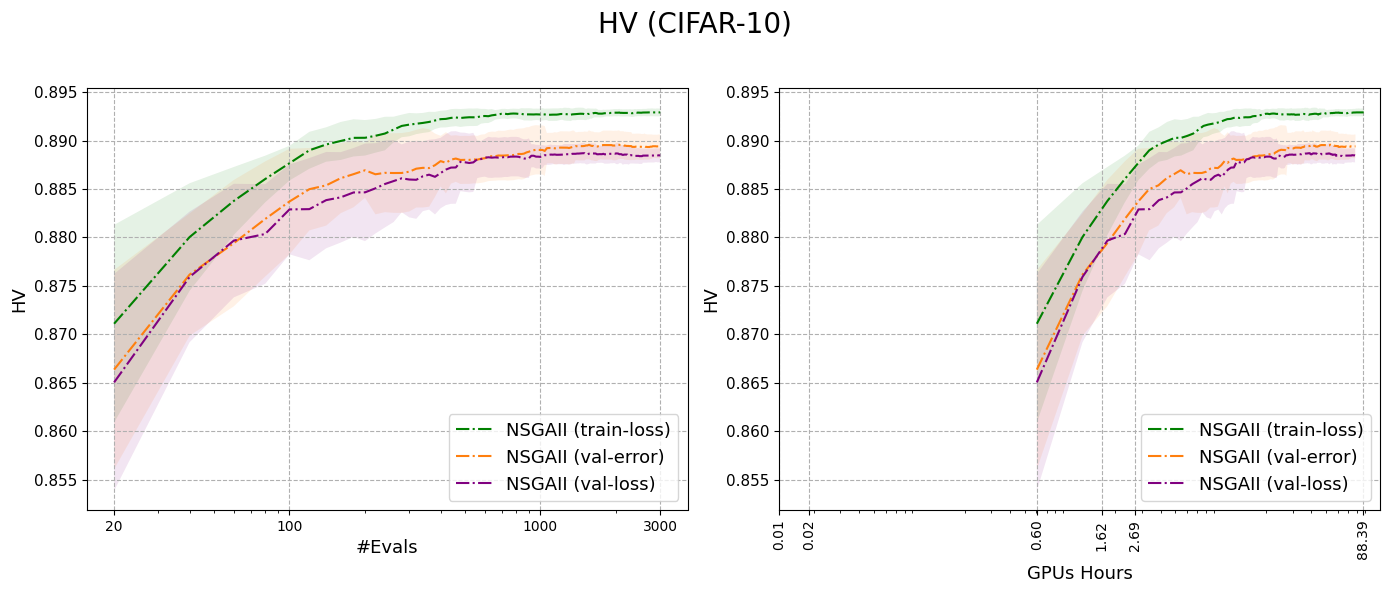

Summarising results
Processing results


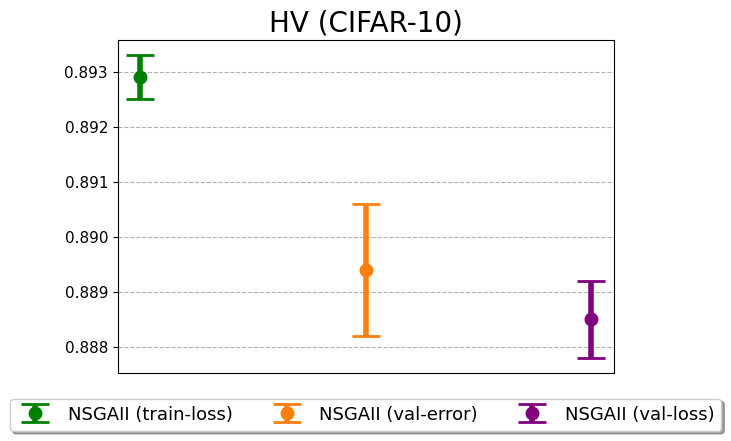

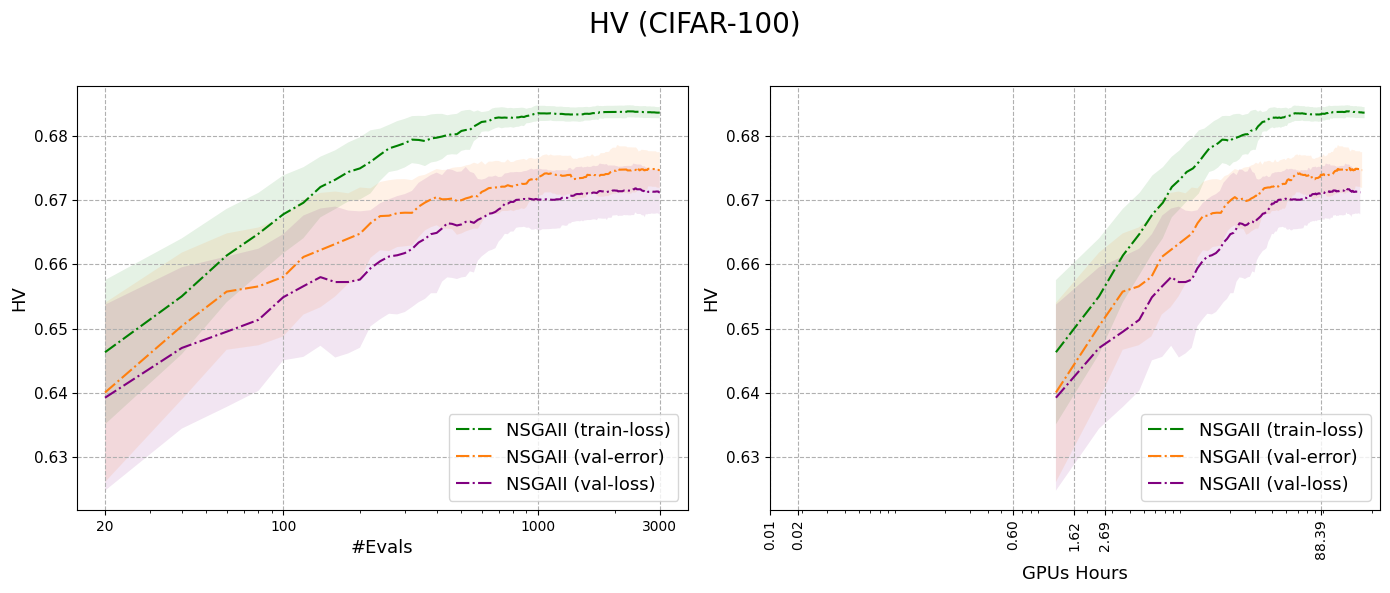

Summarising results
Processing results


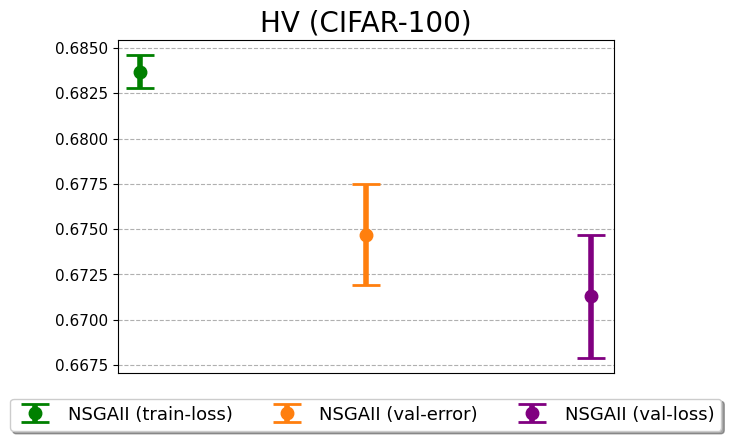

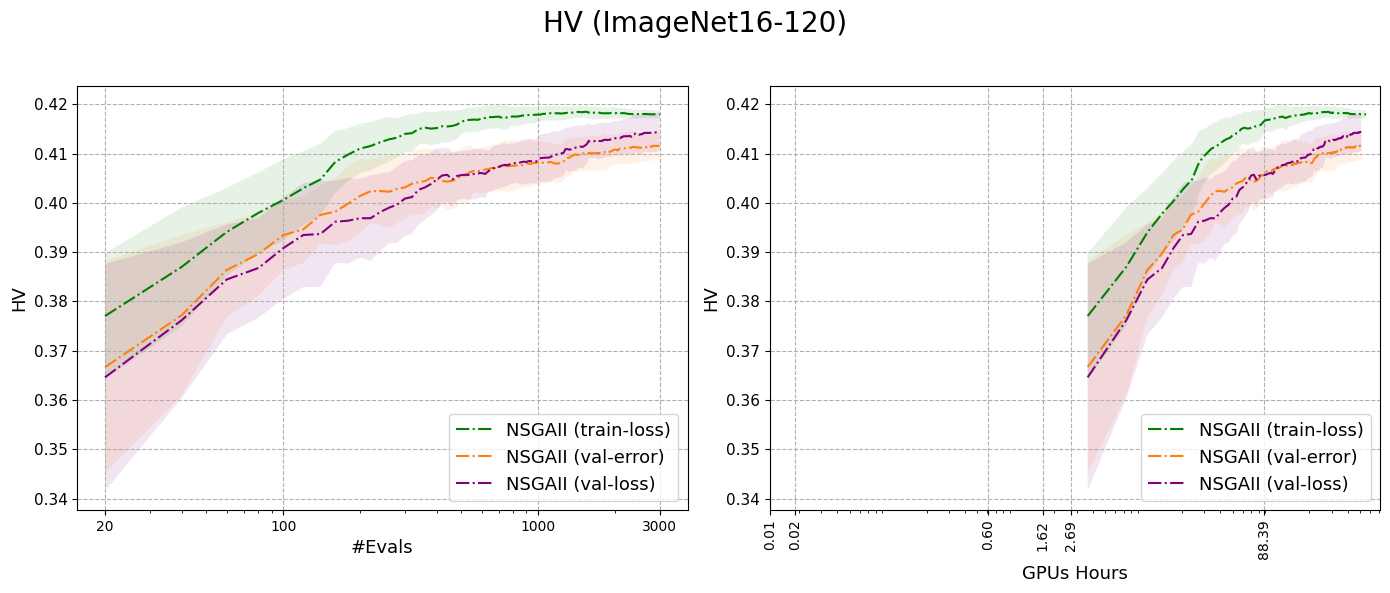

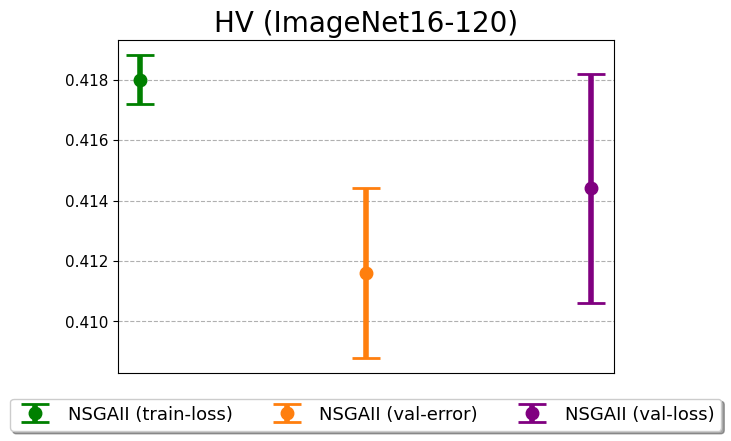

In [16]:
plt.rc('legend', fontsize=13)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=11)
plt.rc('axes', labelsize=13)

RES_PATH = 'results'  # Experiment Results Path
DATABASE_PATH = 'data/NASBench201'  # Database Path
     
metric = 'HV'

datasets = ['CIFAR-10', 'CIFAR-100', 'ImageNet16-120']
for dataset in datasets:
    benchmark_data = p.load(open(DATABASE_PATH + f'/[{dataset}]_data.p', 'rb'))

    if dataset == 'CIFAR-10':
        dataset_abbrev = 'C10'
        min_FLOPs, max_FLOPs = 7.78305, 220.11969  # CIFAR-10
        reference_point = [0.9 + 1e-4, 220.12 + 1e-4]
    elif dataset == 'CIFAR-100':
        dataset_abbrev = 'C100'
        min_FLOPs, max_FLOPs = 7.78890, 220.12554  # CIFAR-100
        reference_point = [0.99 + 1e-4, 220.126 + 1e-4]
    else:
        dataset_abbrev = 'IN16'
        min_FLOPs, max_FLOPs = 1.95340, 55.037560  # ImageNet16-120
        reference_point = [0.9917 + 1e-4, 47.173 + 1e-4]

    benchmark_data = p.load(open(DATABASE_PATH + f'/[{dataset}]_data.p', 'rb'))
    min_FLOPs, max_FLOPs = 7.78305, 220.11969  # CIFAR-10

    HV_computing = HV(ref_point=reference_point)
    summarize_results()
    processing_results()
    metric = 'HV'

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    visualize_xaxis_nEvals() 
    ax = axes[1]
    visualize_xaxis_hours() 

    # Set a figure-level title (centered above both subplots)
    fig.suptitle(f'HV ({dataset})', fontsize=20)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
    plt.savefig(f'{RES_PATH}/{metric}_201_{dataset_abbrev}.jpg', bbox_inches='tight', pad_inches=0.1, dpi=300)
    plt.show()

    ######################

    algo_perf = {'C10': {},'C100': {}, 'IN16': {}}
    list_algo = ['train_loss', 'val_error', 'val_loss']
    for algo in list_algo:
        res = p.load(open(RES_PATH + f'/{algo}_{dataset_abbrev}.p', 'rb'))
        hv = res['final_HV']
        mean_hv, std_hv = np.round(np.mean(hv), 4), np.round(np.std(hv), 4)
        algo_perf[dataset_abbrev][algo] = {'HV': {'mean': {}, 'std': {}}}
        algo_perf[dataset_abbrev][algo]['HV']['mean'] = mean_hv
        algo_perf[dataset_abbrev][algo]['HV']['std'] = std_hv

    draw('HV')


In [ ]:
#summarize_results()

In [ ]:
#processing_results()